# Imports

In [1]:
import pickle

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

## Utils

In [2]:
def dump_pickle(file_obj, file_path):
    with open(file_path, 'bw') as file:
        pickle.dump(file_obj, file)

In [3]:
def plot_distribution(df: pd.DataFrame, column: str, figsize: tuple[int, int] = (12, 5), bins: str = 'auto', kde: bool = True):
    """
    Plota um Histplot e um Boxplot lado a lado para uma variável contínua.
    
    Parâmetros:
    - df: DataFrame do Pandas
    - coluna: String com o nome da coluna a ser analisada
    - figsize: Tupla (largura, altura) do gráfico
    - bins: Configuração de barras do histograma (padrão 'auto')
    - kde: Booleano para incluir a linha de densidade no histograma (padrão True)
    """
    
    print(f"Max Value: {df[column].max()}")
    print(f"Min Value: {df[column].min()}")
    print(f"Median Value: {df[column].median()}")
    print(f"Mean Value: {df[column].mean()}")
    print(f"STD Value: {df[column].std()}")

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    sns.histplot(data=df, x=column, bins=bins, kde=kde, ax=axes[0], color='#4c72b0')
    axes[0].set_title(f'Histograma de {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequência')
    
    sns.boxplot(data=df, x=column, ax=axes[1], color='#fc8d62')
    axes[1].set_title(f'Boxplot de {column}')
    axes[1].set_xlabel(column)
    
    plt.tight_layout()
    
    plt.show()

In [4]:
def plot_categoricals(df, column: str, figsize: tuple[int, int] = (10, 6)):
    """
    Plota um único gráfico de barras horizontais (Countplot) para uma variável categórica.
    
    Parâmetros:
    - df: DataFrame do Pandas
    - column: String com o nome da coluna categórica
    - figsize: Tupla (largura, altura) do gráfico
    - palette: Paleta de cores do Seaborn
    """
   
    print(df[column].value_counts(True))

    plt.figure(figsize=figsize)
    
    order = df[column].value_counts().index
    
    ax = sns.countplot(data=df, y=column, order=order, color='#4c72b0')
    
    ax.set_title(f'Contagem por {column}', fontsize=14, pad=15)
    ax.set_xlabel('Quantidade')
    ax.set_ylabel(column)
    
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0),
                    textcoords='offset points')
    
    sns.despine(right=True, top=True)
    
    plt.tight_layout()
    plt.show()

In [5]:
def plot_cat_vs_target(df, col_categorica: str, col_target: str, target_sucesso: str, figsize: tuple[int, int] = (20, 7)):
    """
    Plota lado a lado a taxa de uma classe específica (sucesso) vs média global (esquerda) 
    e a proporção empilhada 100% de todas as classes do target (direita) para uma variável categórica.
    """
    # Criando a estrutura de 1 linha e 2 colunas lado a lado
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # =========================================================================
    # GRÁFICO 1 (ESQUERDA - axes[0]): Taxa de Sucesso vs Média Global
    # =========================================================================
    df_temp = df.copy()
    # Cria uma flag binária para a classe escolhida como sucesso
    df_temp['is_target'] = (df_temp[col_target].astype(str) == str(target_sucesso)).astype(int)
    
    taxa_por_cat = df_temp.groupby(col_categorica)['is_target'].mean() * 100
    taxa_por_cat = taxa_por_cat.sort_values(ascending=False).reset_index()
    media_global = df_temp['is_target'].mean() * 100
    
    # Plot das barras horizontais azuis
    sns.barplot(
        data=taxa_por_cat, 
        y=col_categorica, 
        x='is_target', 
        color='#4f81bd', 
        width=0.6,
        ax=axes[0]
    )
    
    # Linha da média global laranja
    axes[0].axvline(
        x=media_global, 
        color='#e46c0a', 
        linestyle='--', 
        linewidth=2, 
        label=f'Média Global ({media_global:.1f}%)'
    )
    
    axes[0].set_title(f'Taxa de "{target_sucesso}" em {col_target} por {col_categorica}', fontsize=13, pad=15)
    axes[0].set_xlabel(f'Percentual de "{target_sucesso}" (%)')
    axes[0].set_ylabel(col_categorica)
    axes[0].legend(loc='lower right')
    
    # Rótulos nas barras azuis (Note o uso de axes[0].containers)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold')

    # =========================================================================
    # GRÁFICO 2 (DIREITA - axes[1]): Proporção Empilhada 100% (Multiclasse)
    # =========================================================================
    # Cria a tabela cruzada com todas as classes
    crosstab = pd.crosstab(df[col_categorica], df[col_target])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    
    # Ordena pela categoria que tem maior presença da classe de sucesso (para manter consistência)
    if target_sucesso in crosstab_pct.columns:
        crosstab_pct = crosstab_pct.sort_values(by=target_sucesso, ascending=False)
    
    # Gera cores dinamicamente a partir do Set2 ou color_palette do seaborn de acordo com o número de classes
    num_classes = len(crosstab_pct.columns)
    cores = sns.color_palette("Set2", n_colors=num_classes)
    
    # Plot das barras empilhadas direcionando para o axes[1]
    crosstab_pct.plot(
        kind='barh', 
        stacked=True, 
        color=cores, 
        width=0.7, 
        ax=axes[1]
    )

    axes[1].set_title(f'Proporção de {col_target} por Categoria de {col_categorica}', fontsize=13, pad=15)
    axes[1].set_xlabel('Percentual (%)')
    axes[1].set_ylabel('') 
    axes[1].set_xlim(0, 100)
    axes[1].legend(title=col_target, bbox_to_anchor=(1.02, 1), loc='upper left')

    # Rótulos internos nas barras empilhadas utilizando o container nativo do matplotlib
    for container in axes[1].containers:
        labels = [f'{valor.get_width():.1f}%' if valor.get_width() > 5 else '' for valor in container]
        axes[1].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

    # Customizações finais de layout para ambos os eixos
    sns.despine(ax=axes[0], top=True, right=True)
    sns.despine(ax=axes[1], top=True, right=True)
    
    plt.tight_layout()
    plt.show()

In [6]:
def plot_num_vs_target(df, col_numerica: str, col_target: str, figsize: tuple[int, int] = (14, 5)):
    """
    Plota a relação entre uma variável numérica e uma variável categórica target (Multiclasse).
    Gera automaticamente uma paleta de cores baseada nas classes existentes.
    """
    # Identifica as classes únicas do target de forma dinâmica
    classes_unicas = sorted(df[col_target].dropna().unique())
    num_classes = len(classes_unicas)
    
    # Cria o dicionário de cores dinâmico usando a paleta Set2 (ou outra de sua preferência)
    cores_lista = sns.color_palette("Set2", n_colors=num_classes)
    palette_dict = {classe: cor for classe, cor in zip(classes_unicas, cores_lista)}

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # 1. Boxplot (Esquerda) - Funciona perfeitamente com multiclasse
    sns.boxplot(
        data=df, 
        x=col_target, 
        y=col_numerica, 
        hue=col_target, 
        legend=False, 
        ax=axes[0], 
        palette=palette_dict
    )
    axes[0].set_title(f'Distribuição de {col_numerica} por {col_target}')
    axes[0].set_xlabel(col_target)
    axes[0].set_ylabel(col_numerica)
    
    # 2. KDE Plot (Direita) - Substituído o Barplot por um gráfico de densidade,
    # que é o ideal para comparar distribuições numéricas entre múltiplas classes.
    sns.kdeplot(
        data=df,
        x=col_numerica,
        hue=col_target,
        fill=True,
        common_norm=False,  # Permite avaliar o formato de cada classe de forma independente
        alpha=0.4,
        palette=palette_dict,
        ax=axes[1]
    )
    axes[1].set_title(f'Densidade (KDE) de {col_numerica} por {col_target}')
    axes[1].set_xlabel(col_numerica)
    axes[1].set_ylabel('Densidade')
    
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

# Loading Datasets

In [7]:
df = pd.read_csv('../data/raw/train.csv', index_col='id')
df_test = pd.read_csv('../data/raw/test.csv', index_col='id')

In [8]:
df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,,
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [9]:
df.tail()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,,
690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


## Data Columns

In [10]:
df.columns.tolist()

['health_condition',
 'sleep_duration',
 'heart_rate',
 'bmi',
 'calorie_expenditure',
 'step_count',
 'exercise_duration',
 'water_intake',
 'diet_type',
 'stress_level',
 'sleep_quality',
 'physical_activity_level',
 'smoking_alcohol',
 'gender']

## Data Dimensions

In [11]:
df.shape

(690088, 14)

## Data NA

In [12]:
df.isna().mean()

health_condition           0.000000
sleep_duration             0.110129
heart_rate                 0.011351
bmi                        0.020139
calorie_expenditure        0.076589
step_count                 0.020166
exercise_duration          0.010000
water_intake               0.063002
diet_type                  0.010000
stress_level               0.120001
sleep_quality              0.084527
physical_activity_level    0.053067
smoking_alcohol            0.041418
gender                     0.030971
dtype: float64

## Data Types

In [13]:
df.dtypes

health_condition               str
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
dtype: object

# Exploratory Data Analysis

## Univariate Data Analysis

### Sleep Duration

Max Value: 10.0
Min Value: 3.0
Median Value: 6.99
Mean Value: 6.992597310813253
STD Value: 1.2154067205430614


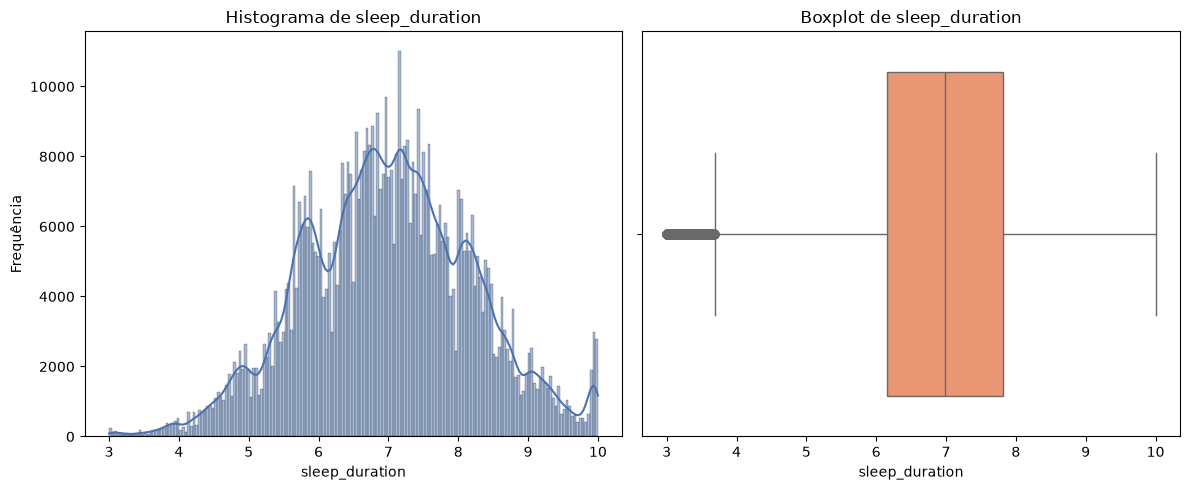

In [14]:
plot_distribution(df, 'sleep_duration')

### Heart Rate

Max Value: 107.7
Min Value: 50.0
Median Value: 75.1
Mean Value: 75.09650428358898
STD Value: 8.175106424643563


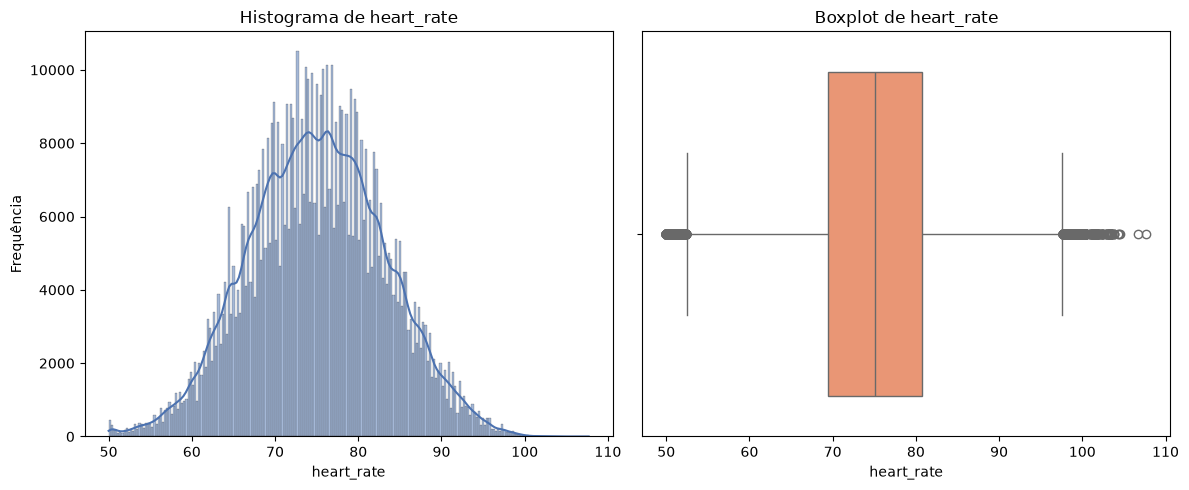

In [15]:
plot_distribution(df, 'heart_rate')

### BMI

Max Value: 34.82
Min Value: 16.0
Median Value: 22.99
Mean Value: 22.98492504917257
STD Value: 2.481786645204862


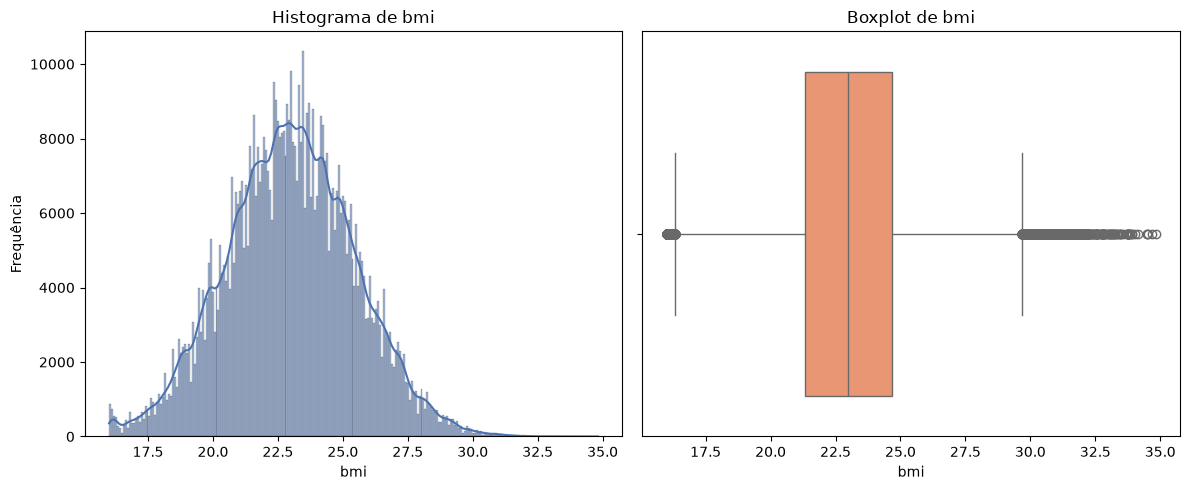

In [16]:
plot_distribution(df, 'bmi')

### Calorie Expendure

Max Value: 3580.0
Min Value: 1200.0
Median Value: 2241.0
Mean Value: 2226.0849309909217
STD Value: 347.5320976009461


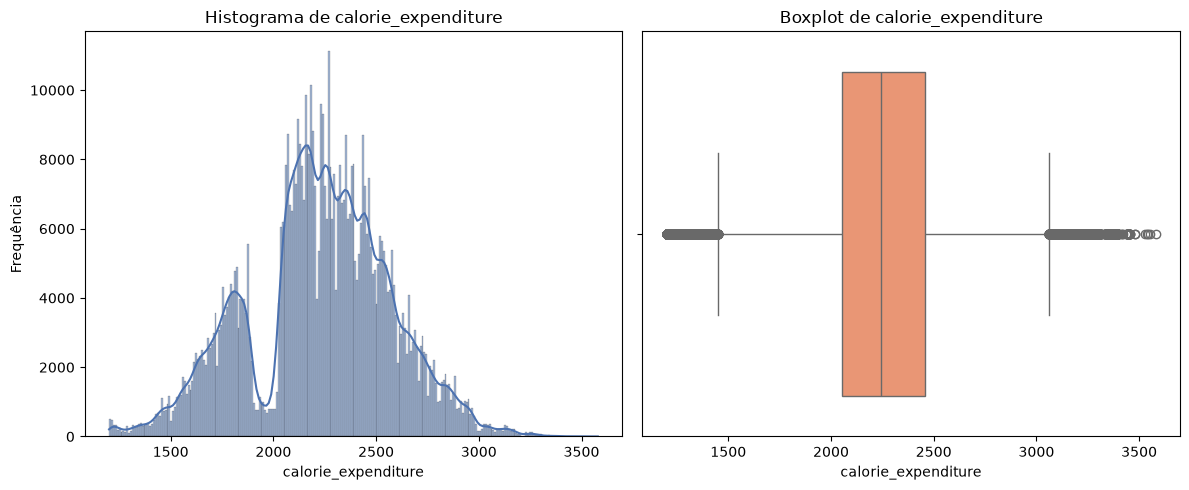

In [18]:
plot_distribution(df, 'calorie_expenditure')

### Step Count

Max Value: 14999.0
Min Value: 1002.0
Median Value: 8856.0
Mean Value: 8615.953050407294
STD Value: 3929.399830758335


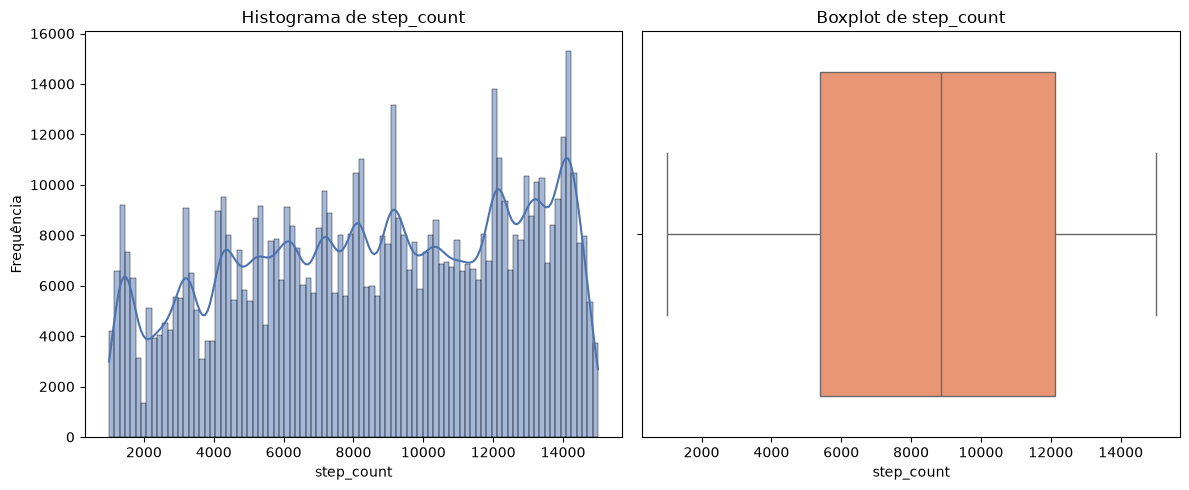

In [19]:
plot_distribution(df, 'step_count')

### Exercise Duration

Max Value: 99.8
Min Value: 0.0
Median Value: 39.4
Mean Value: 38.75145557512072
STD Value: 14.742189352252645


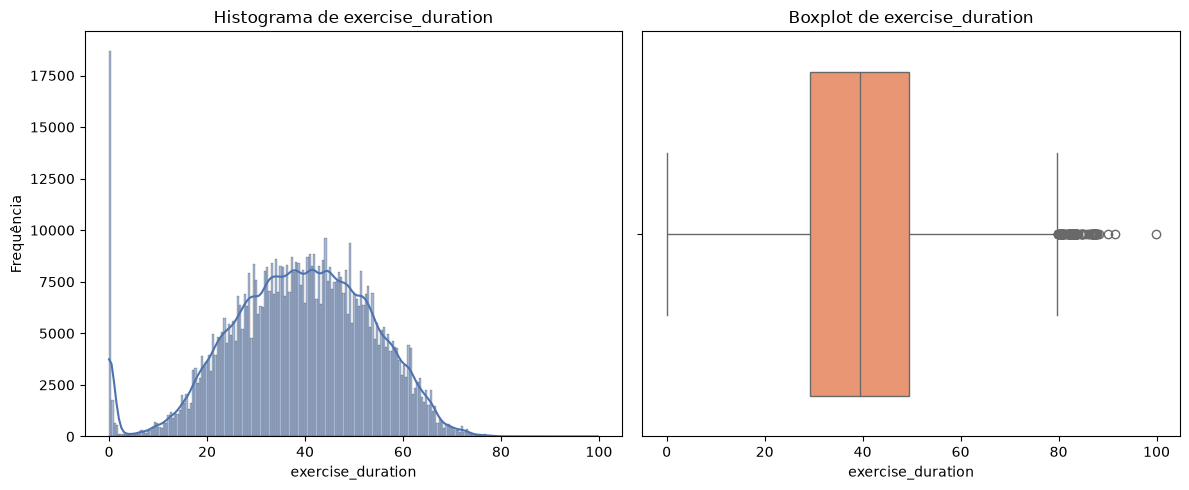

In [20]:
plot_distribution(df, 'exercise_duration')

### Water Intake

Max Value: 4.72
Min Value: 0.5
Median Value: 2.17
Mean Value: 2.18854223018167
STD Value: 0.5184894887561875


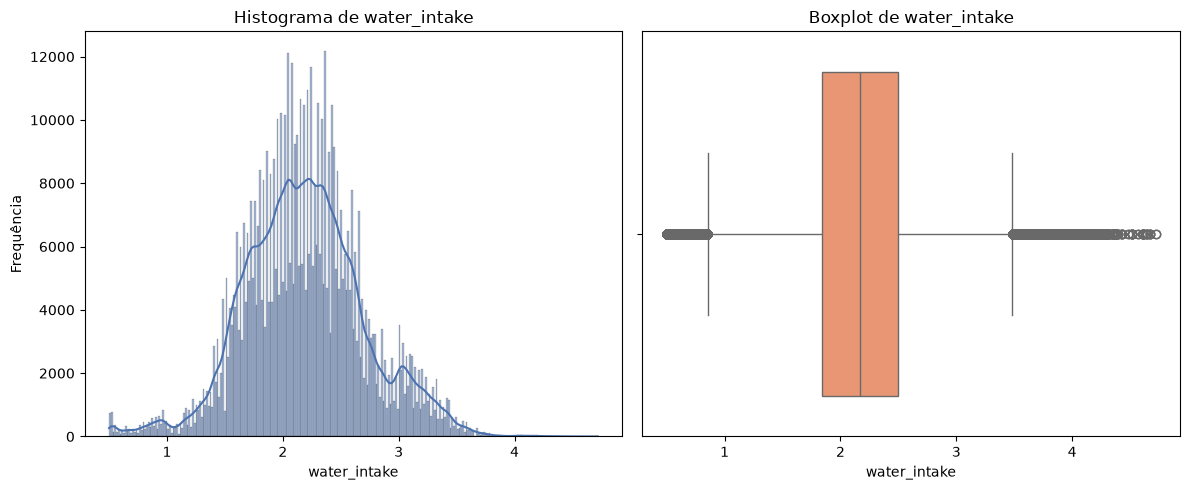

In [21]:
plot_distribution(df, 'water_intake')

### Diet Type

diet_type
veg         0.338754
balanced    0.332102
non-veg     0.329144
Name: proportion, dtype: float64


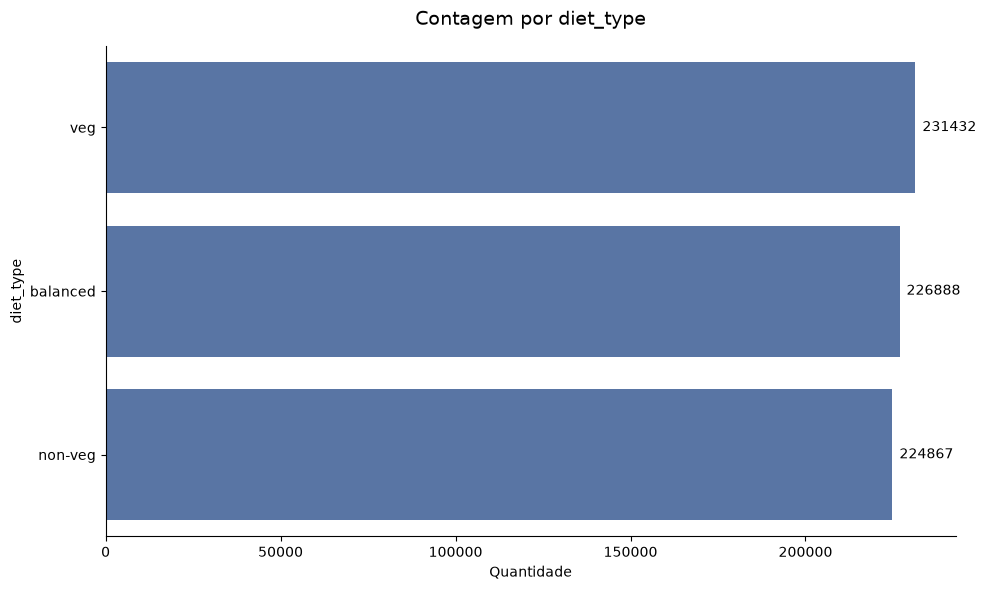

In [22]:
plot_categoricals(df, 'diet_type')

### Stress Level

stress_level
medium    0.431136
high      0.292700
low       0.276164
Name: proportion, dtype: float64


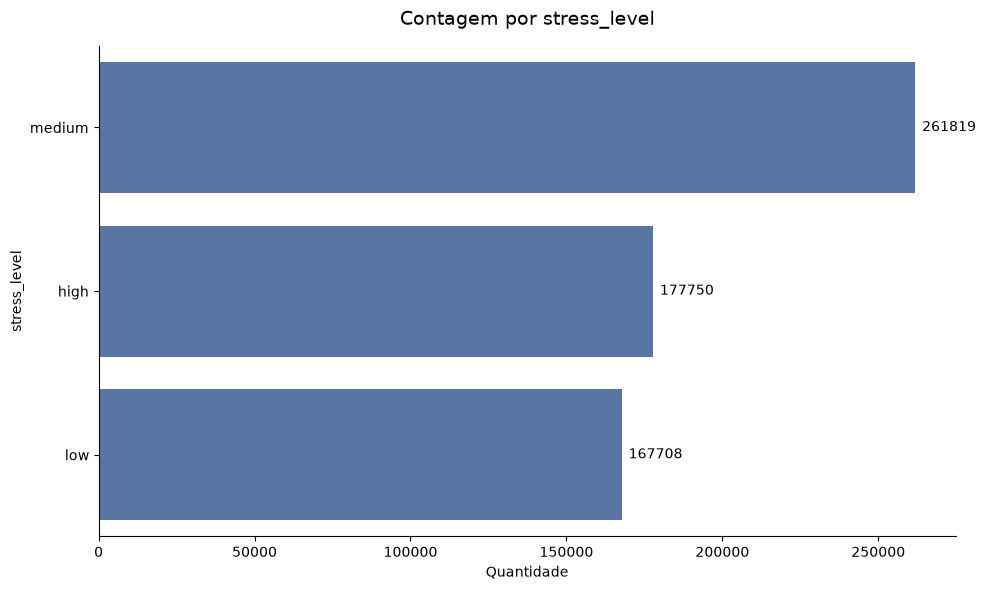

In [23]:
plot_categoricals(df, 'stress_level')

### Sleep Quality

sleep_quality
average    0.338656
poor       0.335835
good       0.325510
Name: proportion, dtype: float64


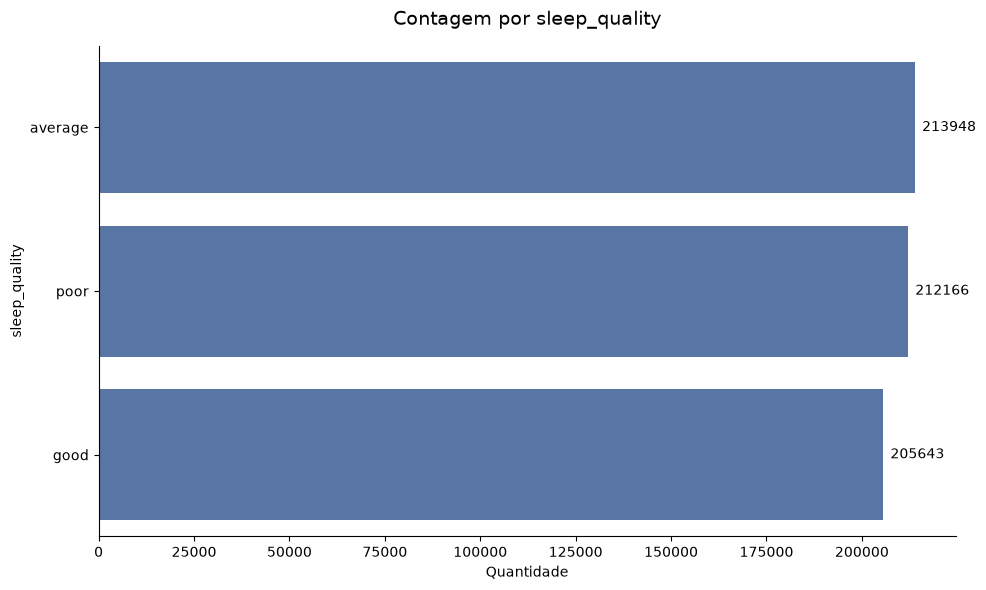

In [24]:
plot_categoricals(df, 'sleep_quality')

### Physical Activity Level

physical_activity_level
moderate     0.338259
sedentary    0.336335
active       0.325406
Name: proportion, dtype: float64


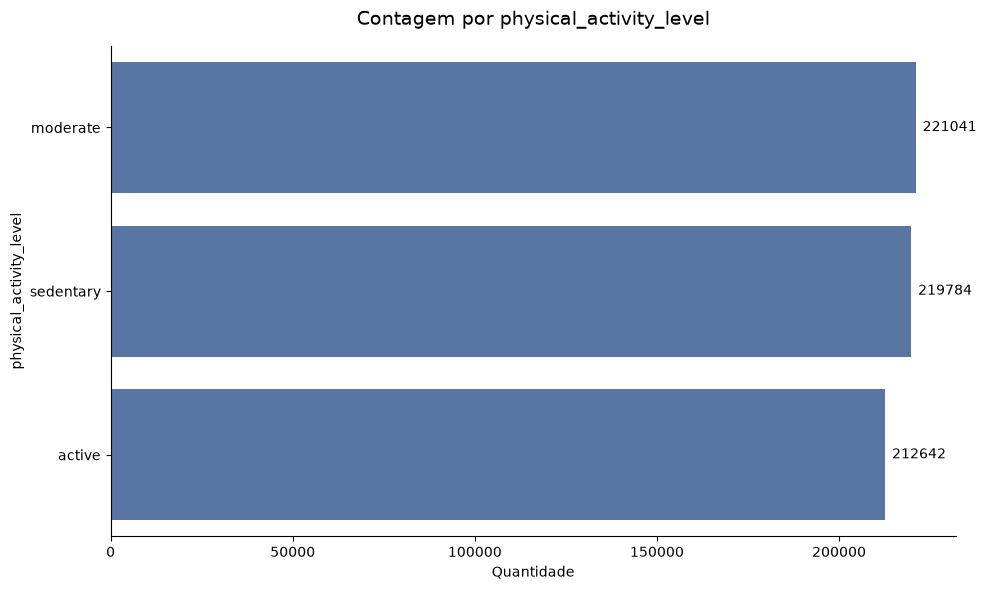

In [25]:
plot_categoricals(df, 'physical_activity_level')

### Smoking Alcohol

smoking_alcohol
yes           0.338213
no            0.332259
occasional    0.329528
Name: proportion, dtype: float64


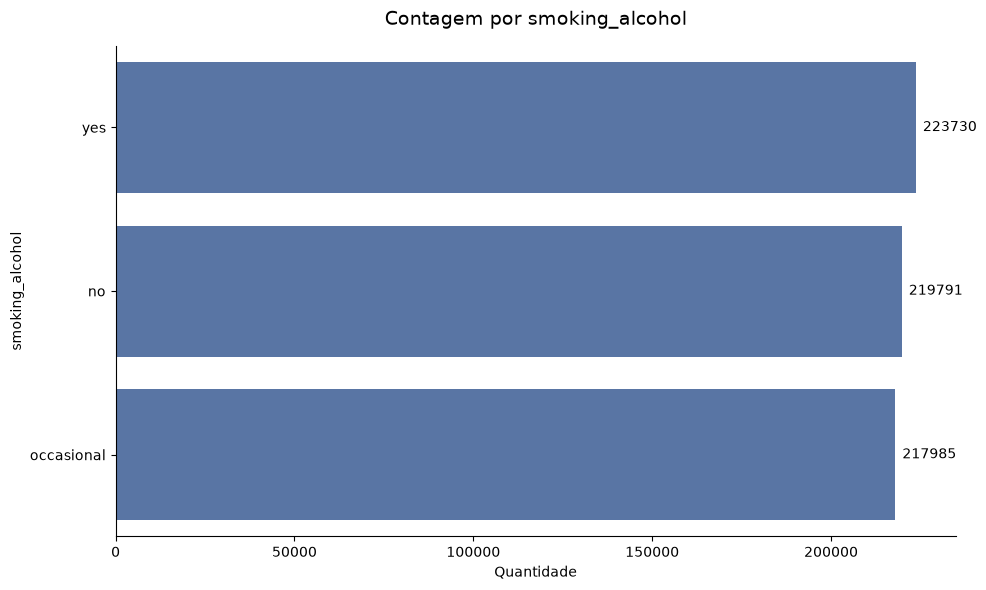

In [26]:
plot_categoricals(df, 'smoking_alcohol')

### Gender

gender
male      0.355542
female    0.334995
other     0.309464
Name: proportion, dtype: float64


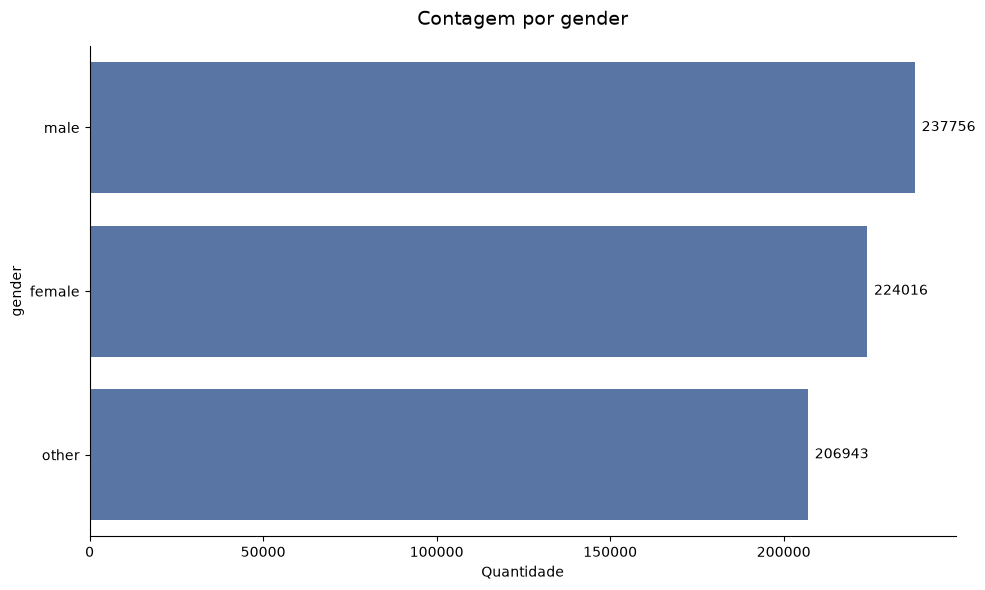

In [27]:
plot_categoricals(df, 'gender')

### Health Condition

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64


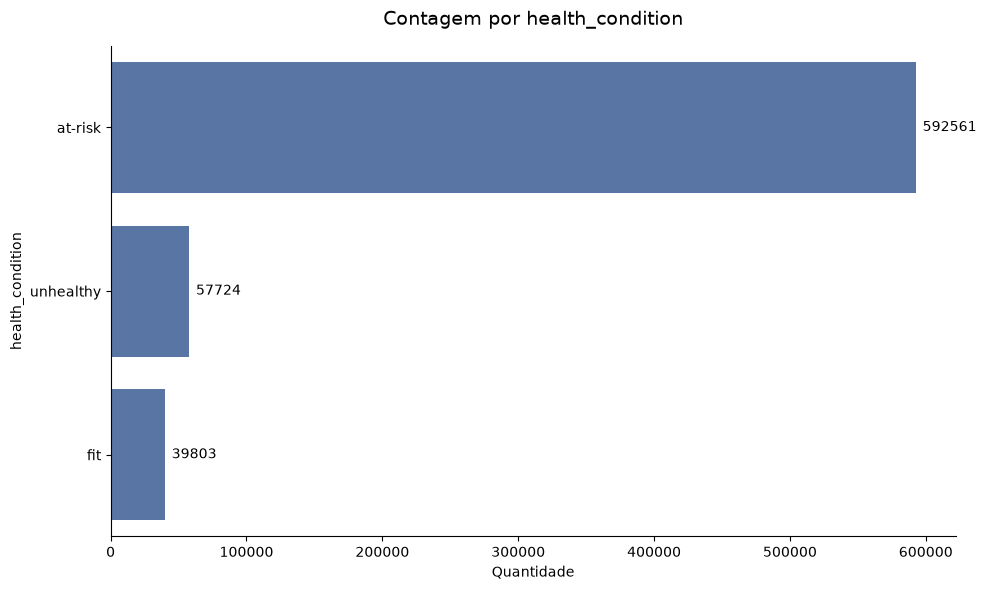

In [28]:
plot_categoricals(df, 'health_condition')

## Bivariate Analysis

### sleep duration vs health condition

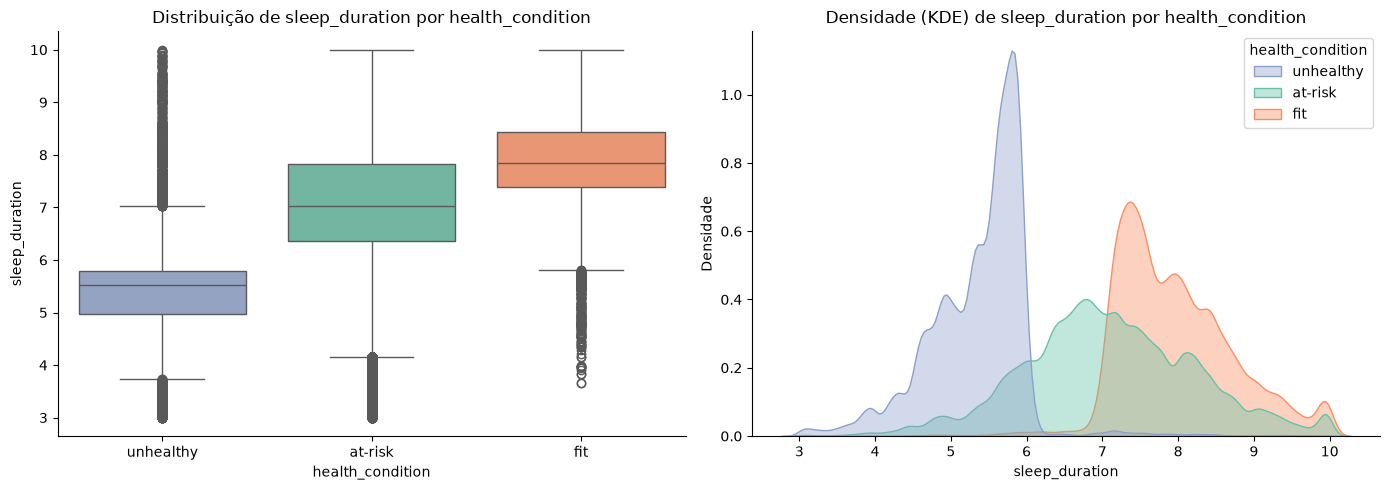

In [29]:
plot_num_vs_target(df, col_numerica='sleep_duration', col_target='health_condition')

### heart rate vs health codition

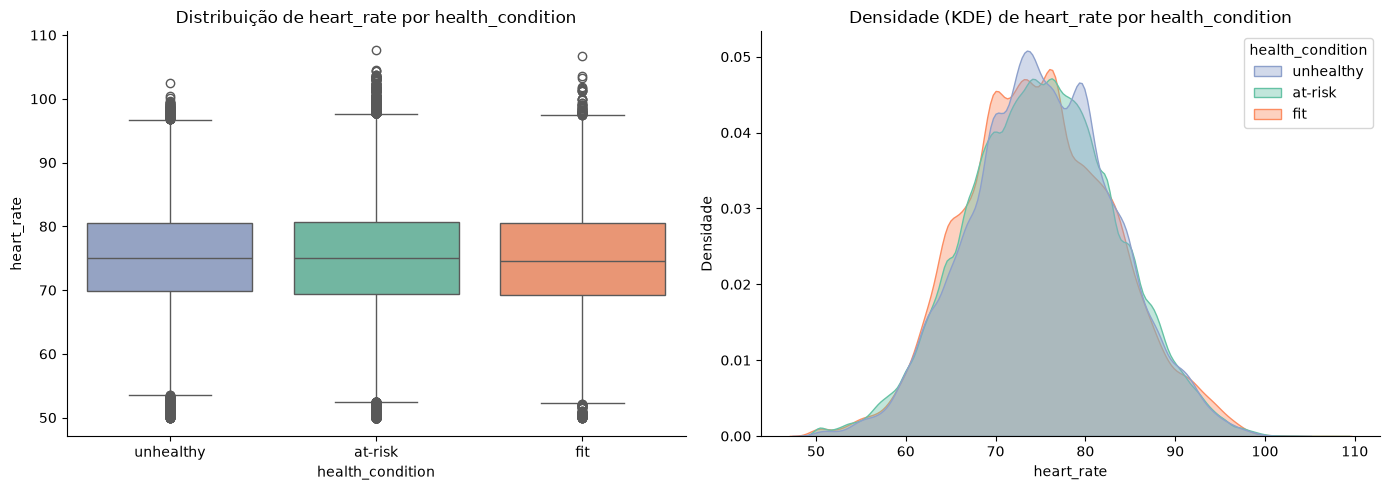

In [30]:
plot_num_vs_target(df, col_numerica='heart_rate', col_target='health_condition')

### bmi vs health condition

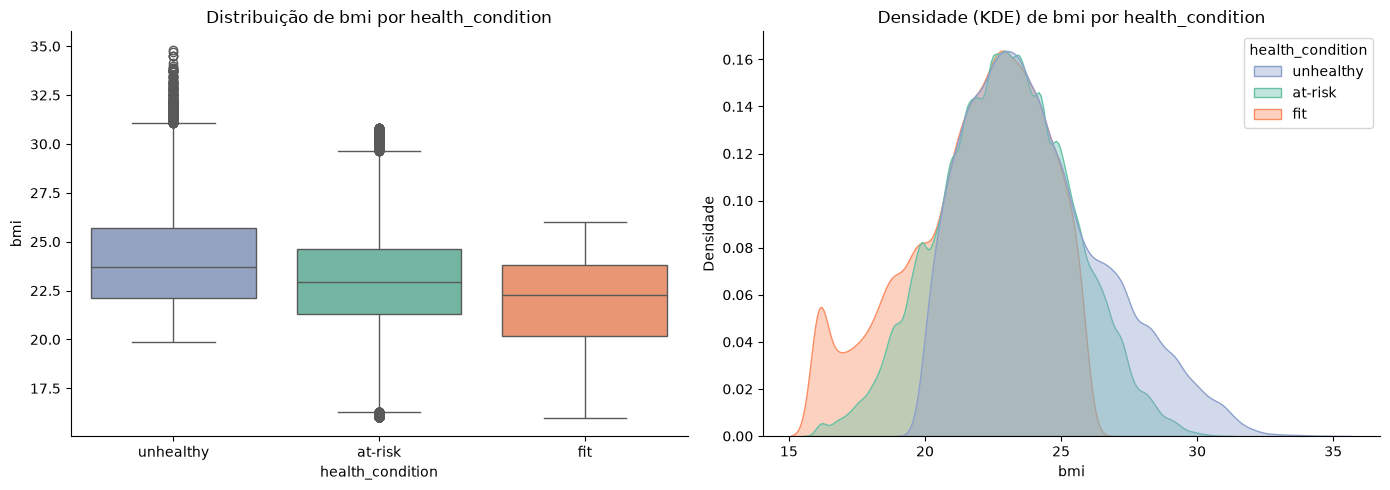

In [31]:
plot_num_vs_target(df, col_numerica='bmi', col_target='health_condition')

### calorie expenditure vs health condition

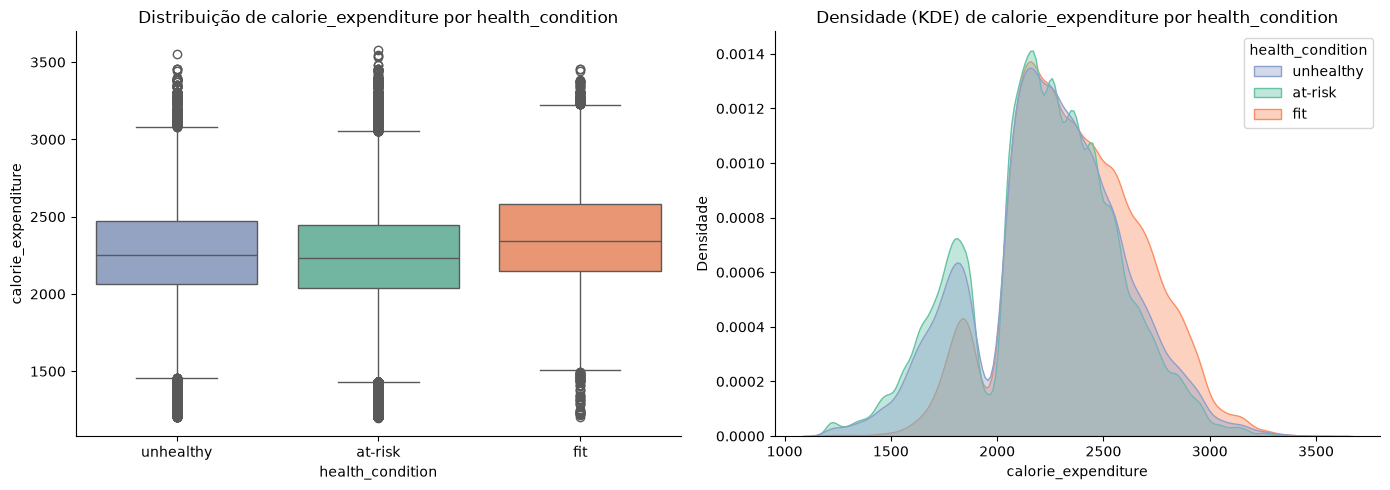

In [35]:
plot_num_vs_target(df, col_numerica='calorie_expenditure', col_target='health_condition')

### step count vs health condition

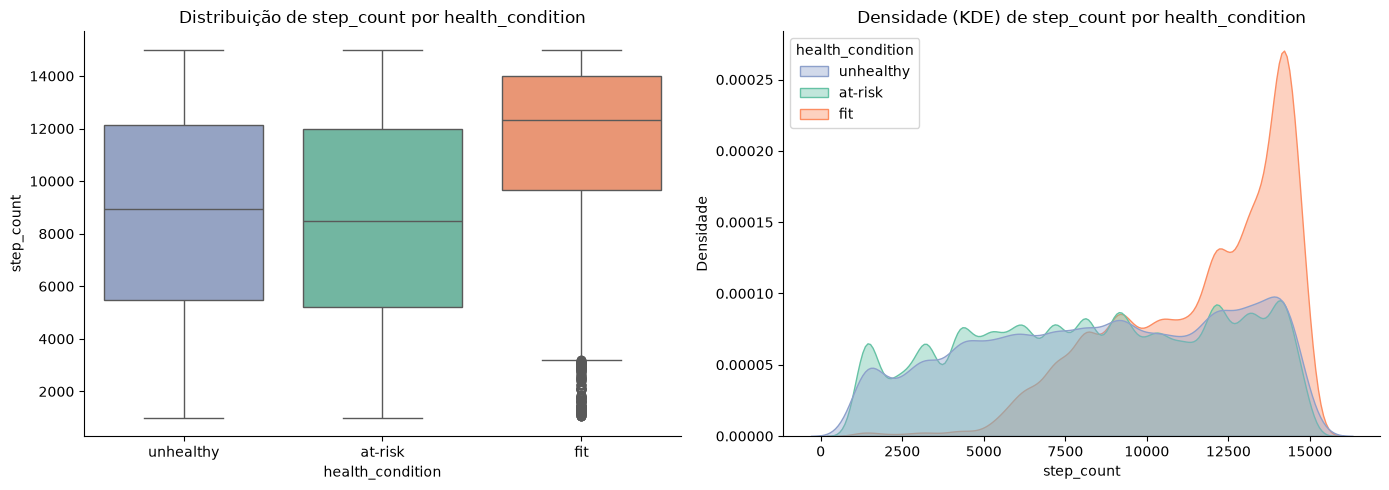

In [36]:
plot_num_vs_target(df, col_numerica='step_count', col_target='health_condition')

### Exercise vs Health Condition

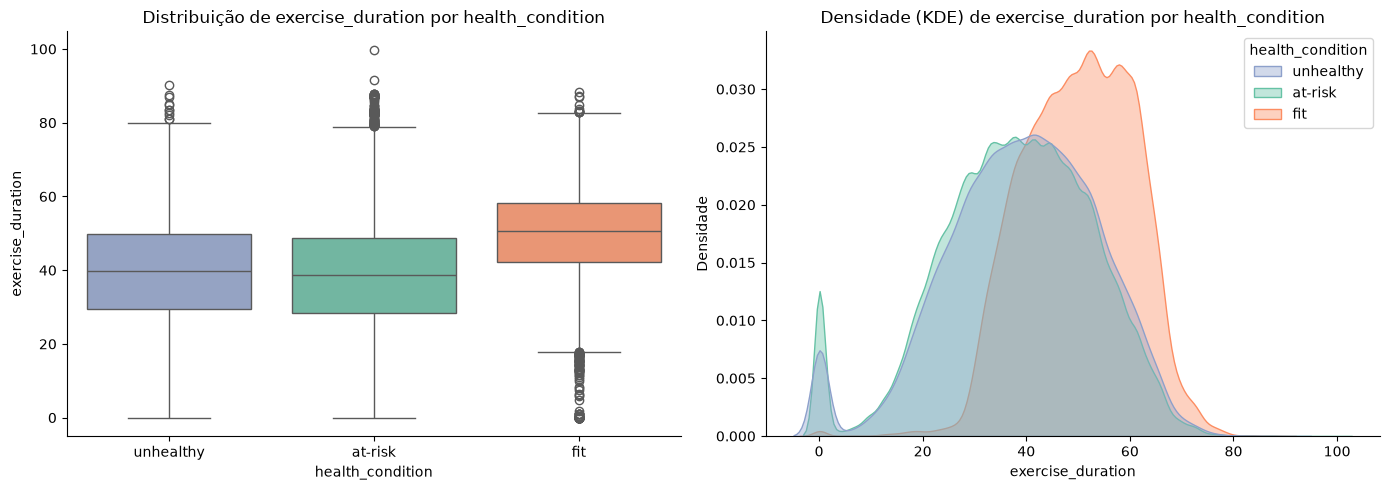

In [38]:
plot_num_vs_target(df, col_numerica='exercise_duration', col_target='health_condition')

### Water Intake vs Health Condition

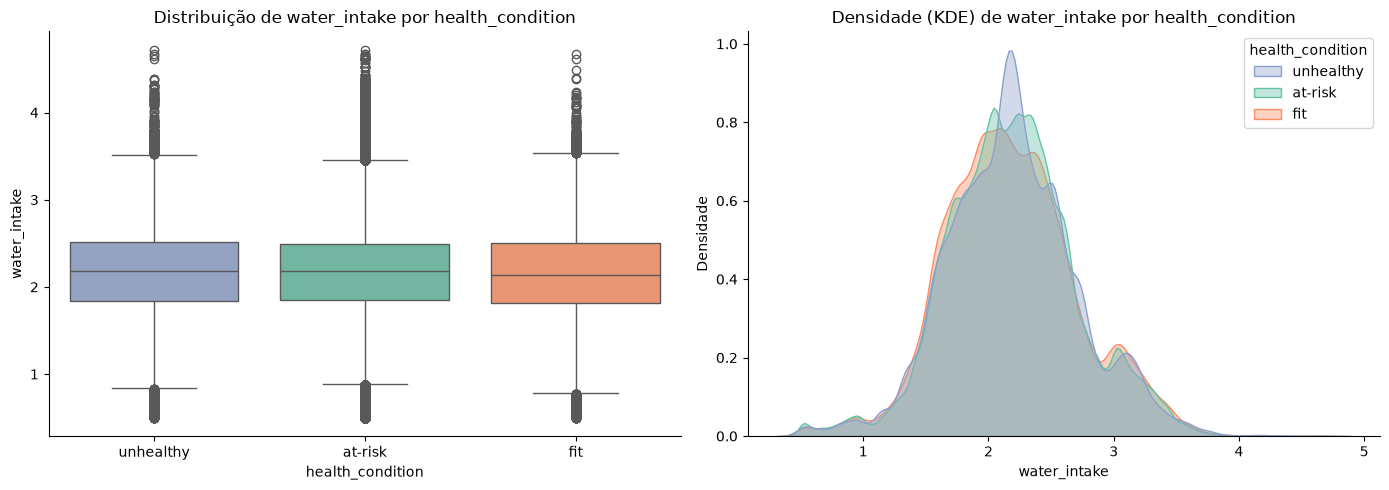

In [39]:
plot_num_vs_target(df, col_numerica='water_intake', col_target='health_condition')

### Diet Type vs Health Condition

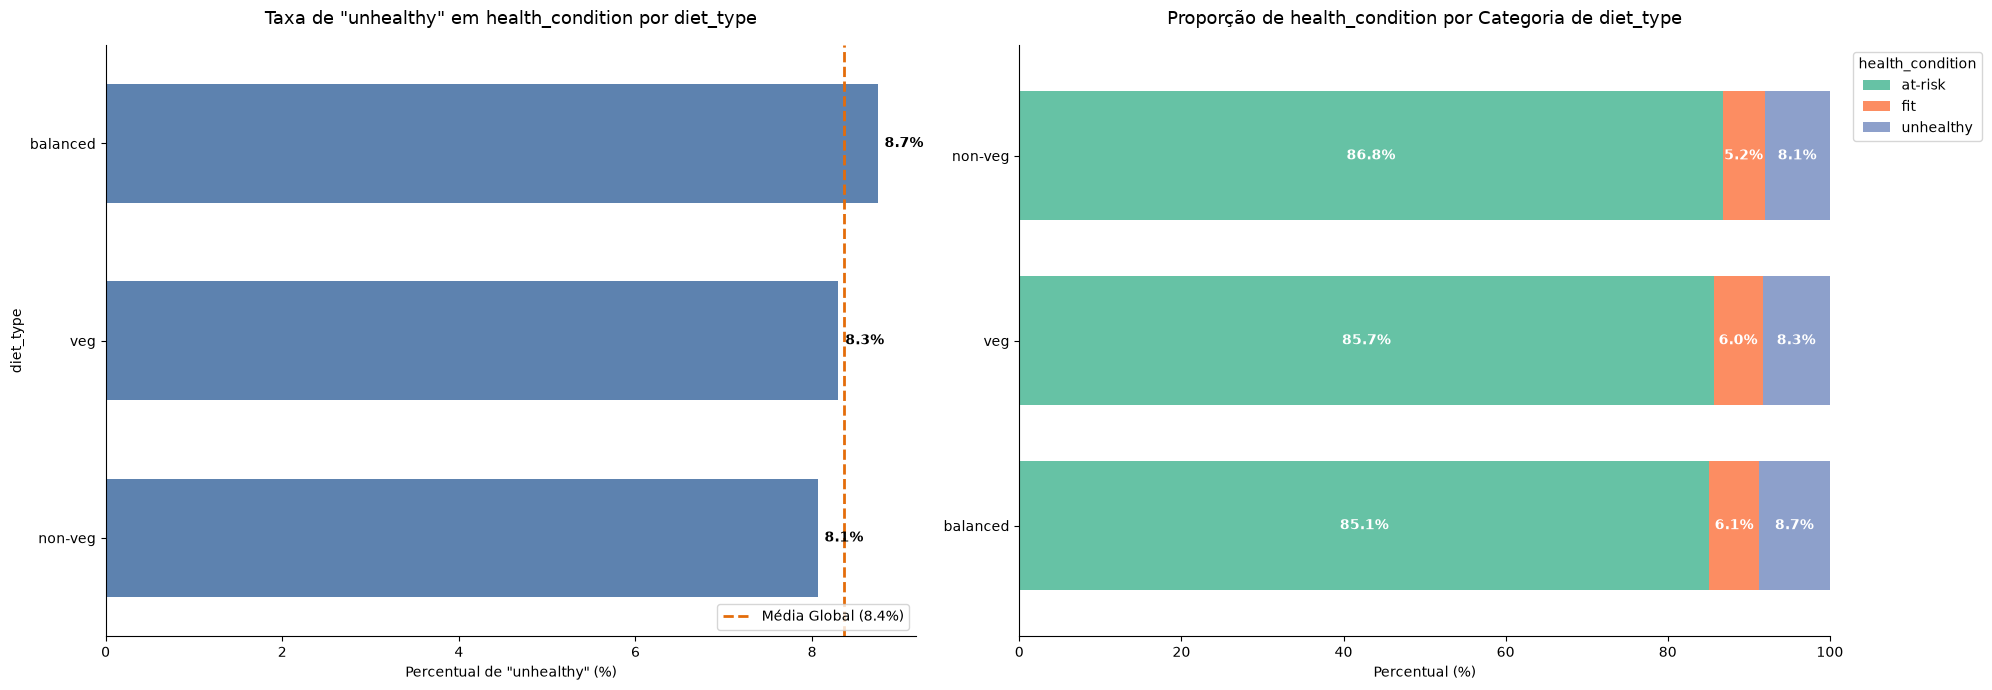

In [51]:
plot_cat_vs_target(df, col_categorica='diet_type', col_target='health_condition', target_sucesso='unhealthy')

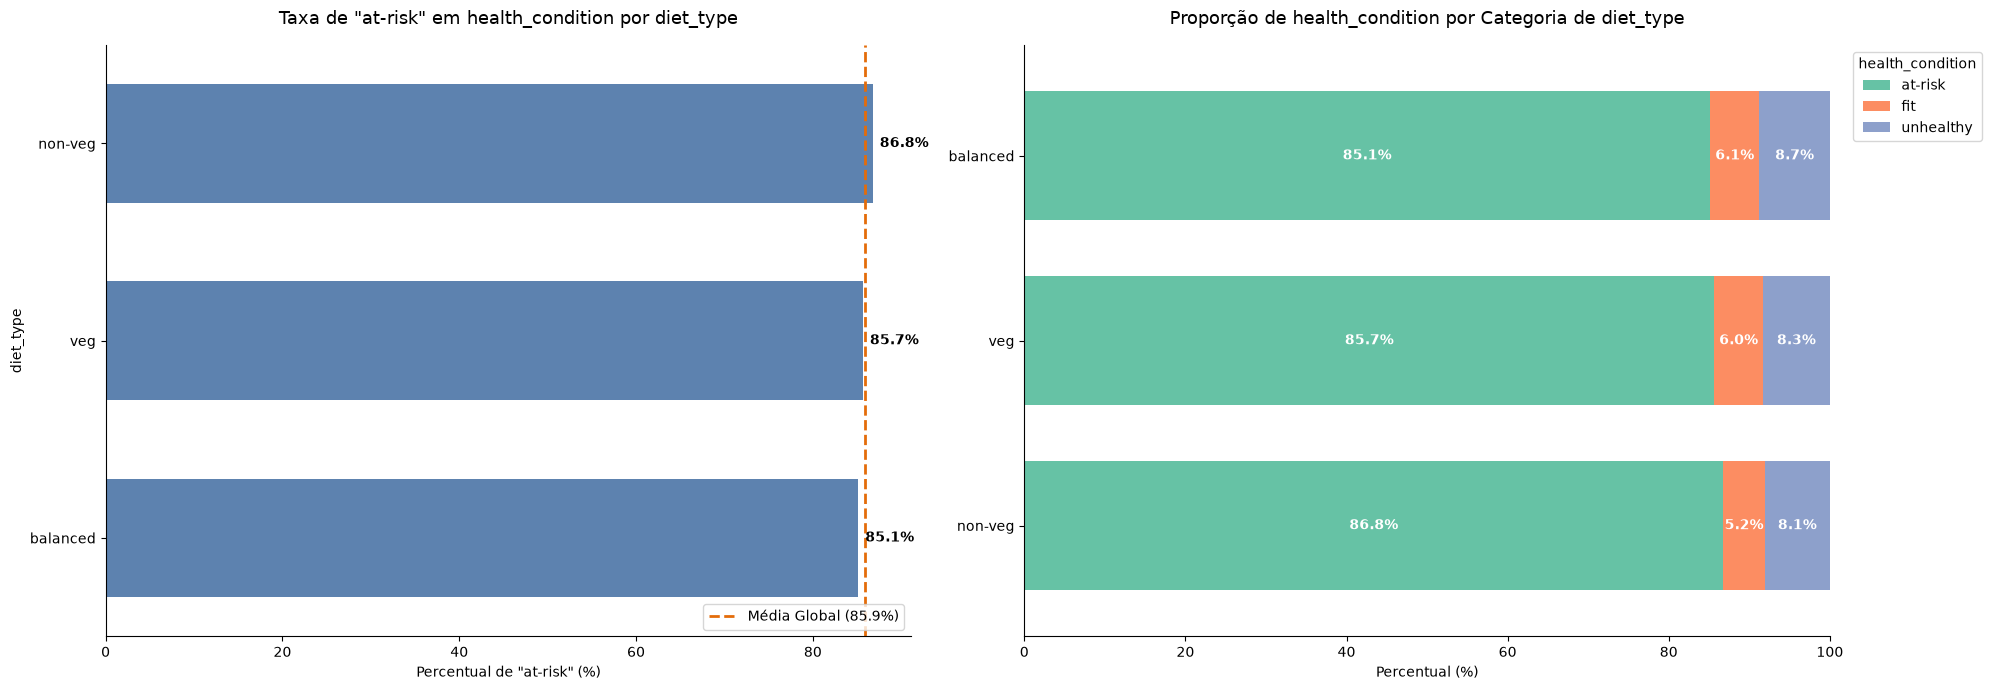

In [52]:
plot_cat_vs_target(df, col_categorica='diet_type', col_target='health_condition', target_sucesso='at-risk')

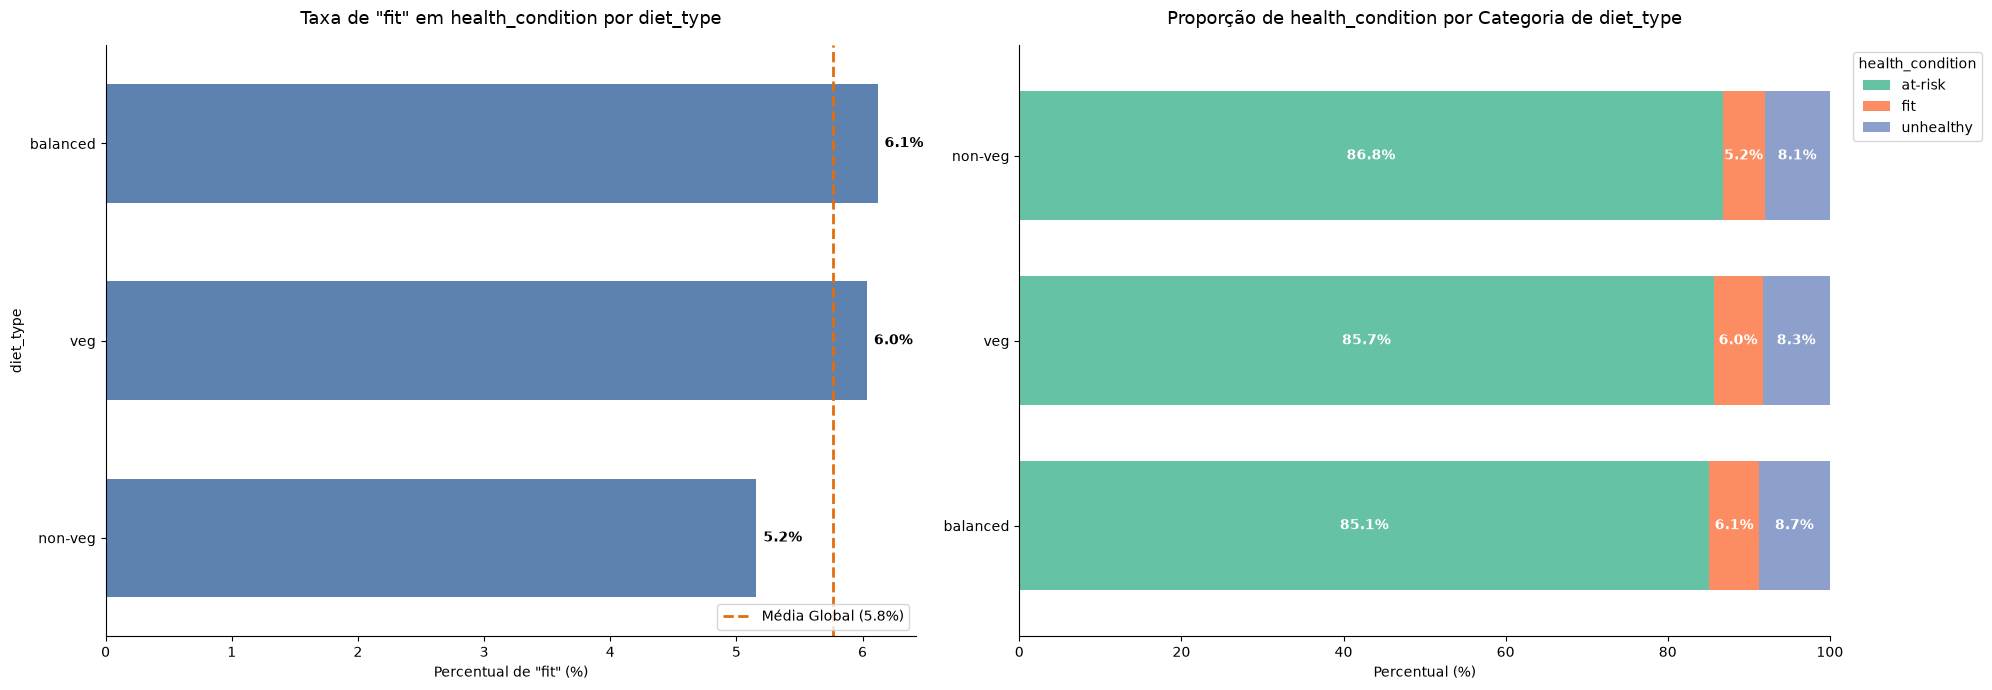

In [53]:
plot_cat_vs_target(df, col_categorica='diet_type', col_target='health_condition', target_sucesso='fit')

### Stress Level

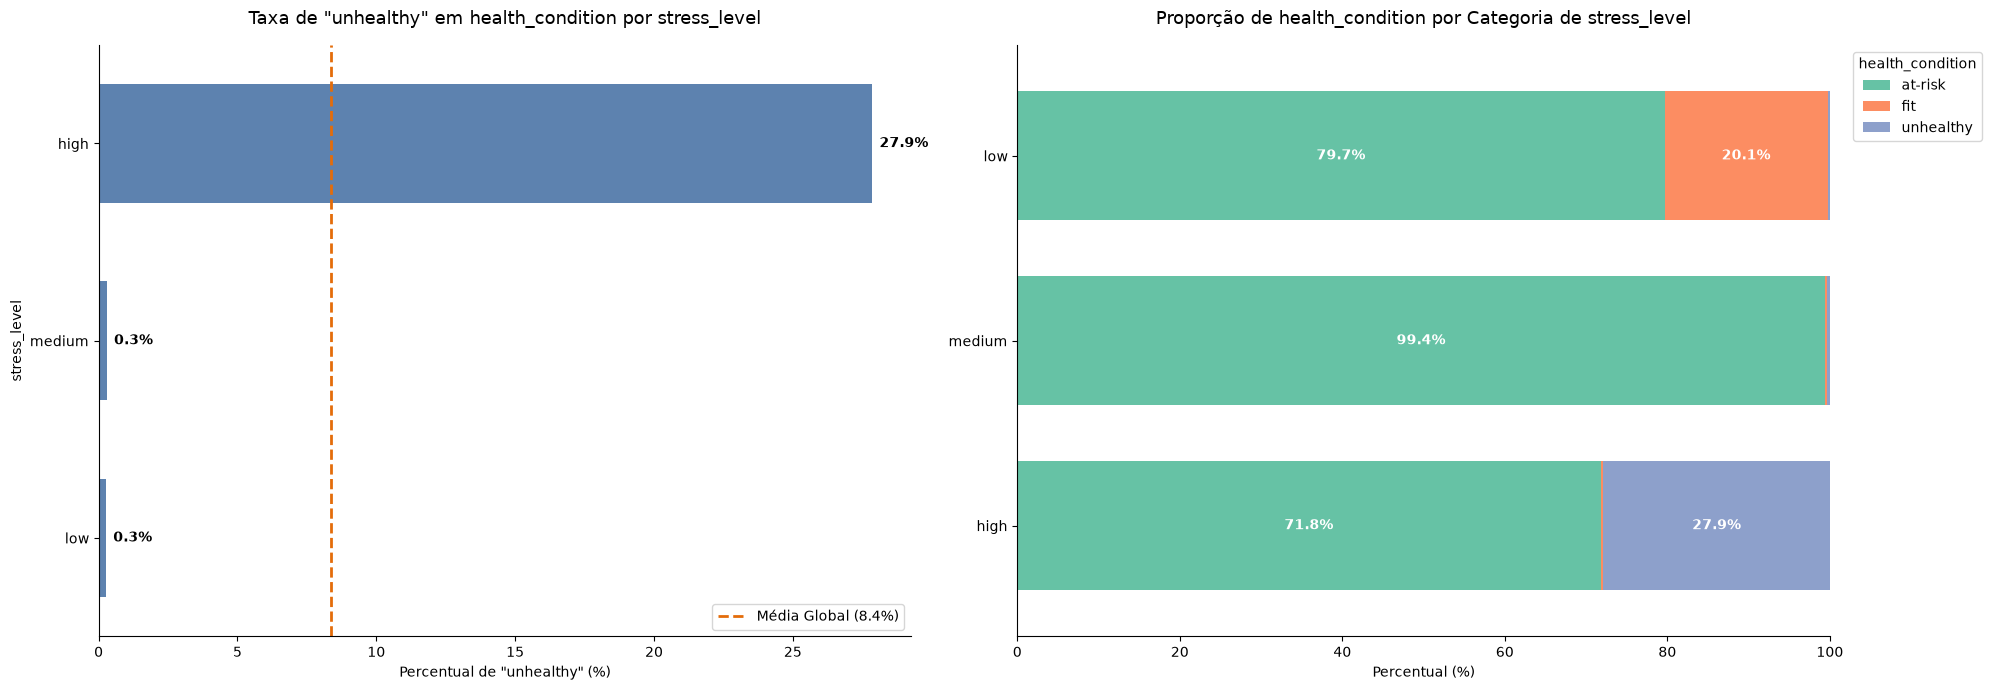

In [55]:
plot_cat_vs_target(df, col_categorica='stress_level', col_target='health_condition', target_sucesso='unhealthy')

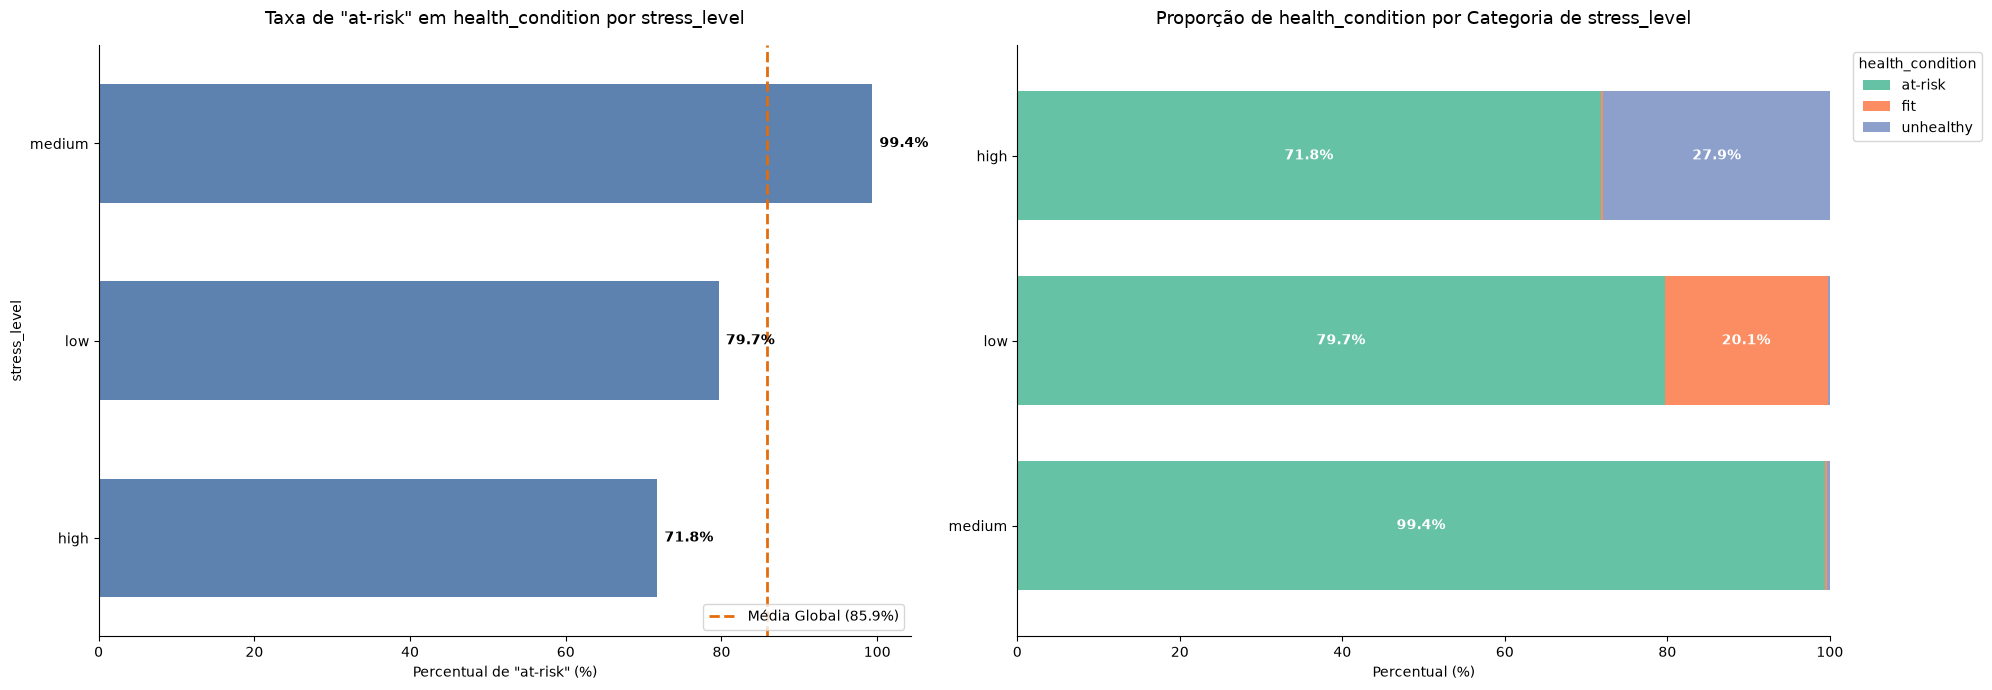

In [56]:
plot_cat_vs_target(df, col_categorica='stress_level', col_target='health_condition', target_sucesso='at-risk')

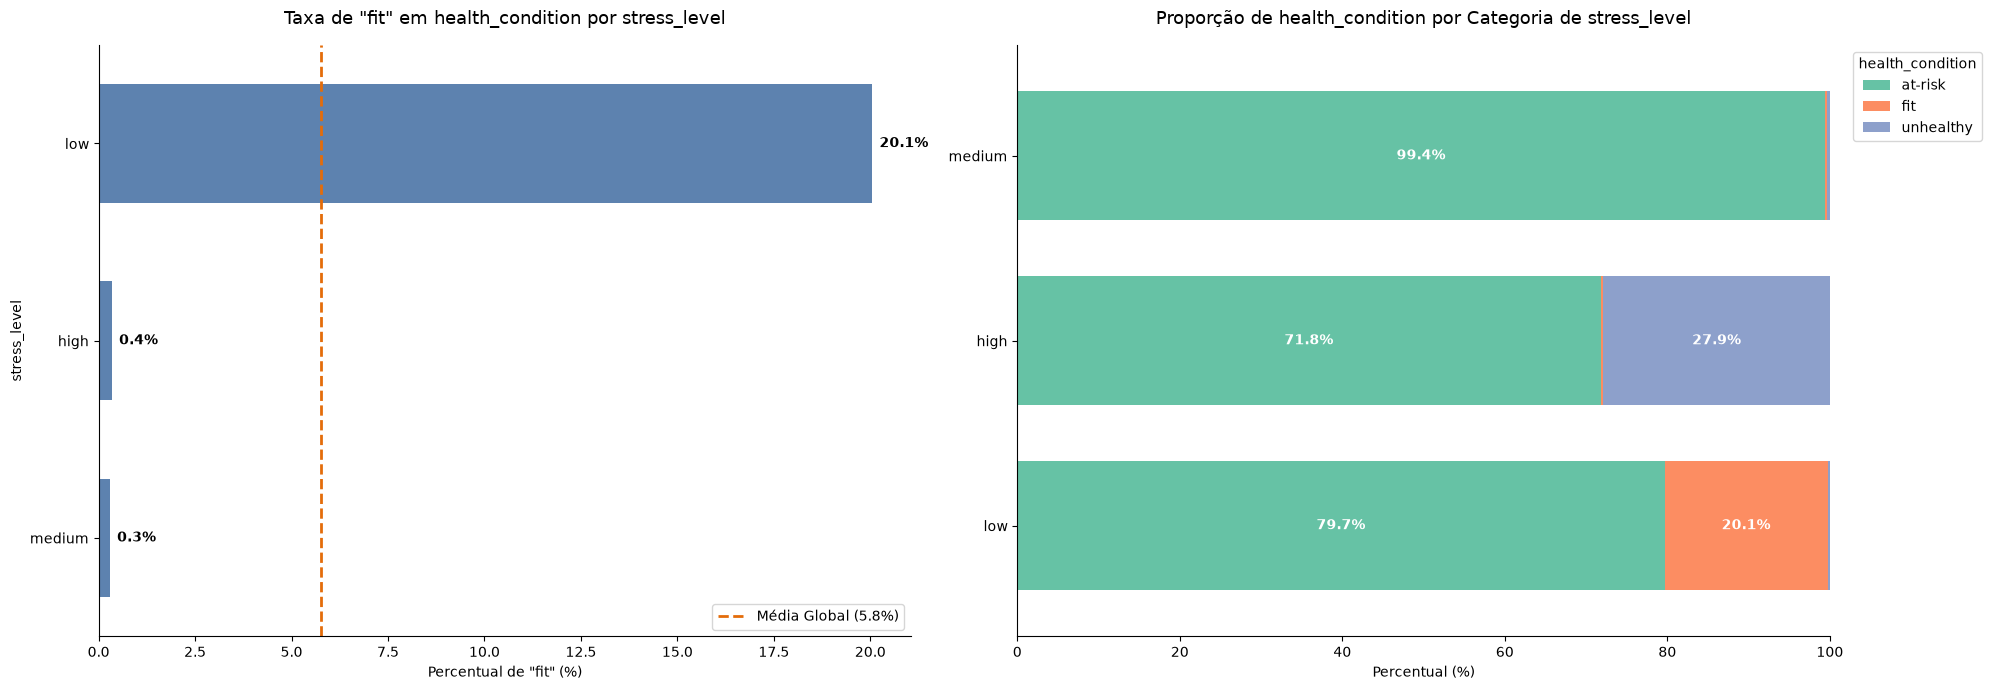

In [57]:
plot_cat_vs_target(df, col_categorica='stress_level', col_target='health_condition', target_sucesso='fit')

### Sleep Quality vs Health Condition

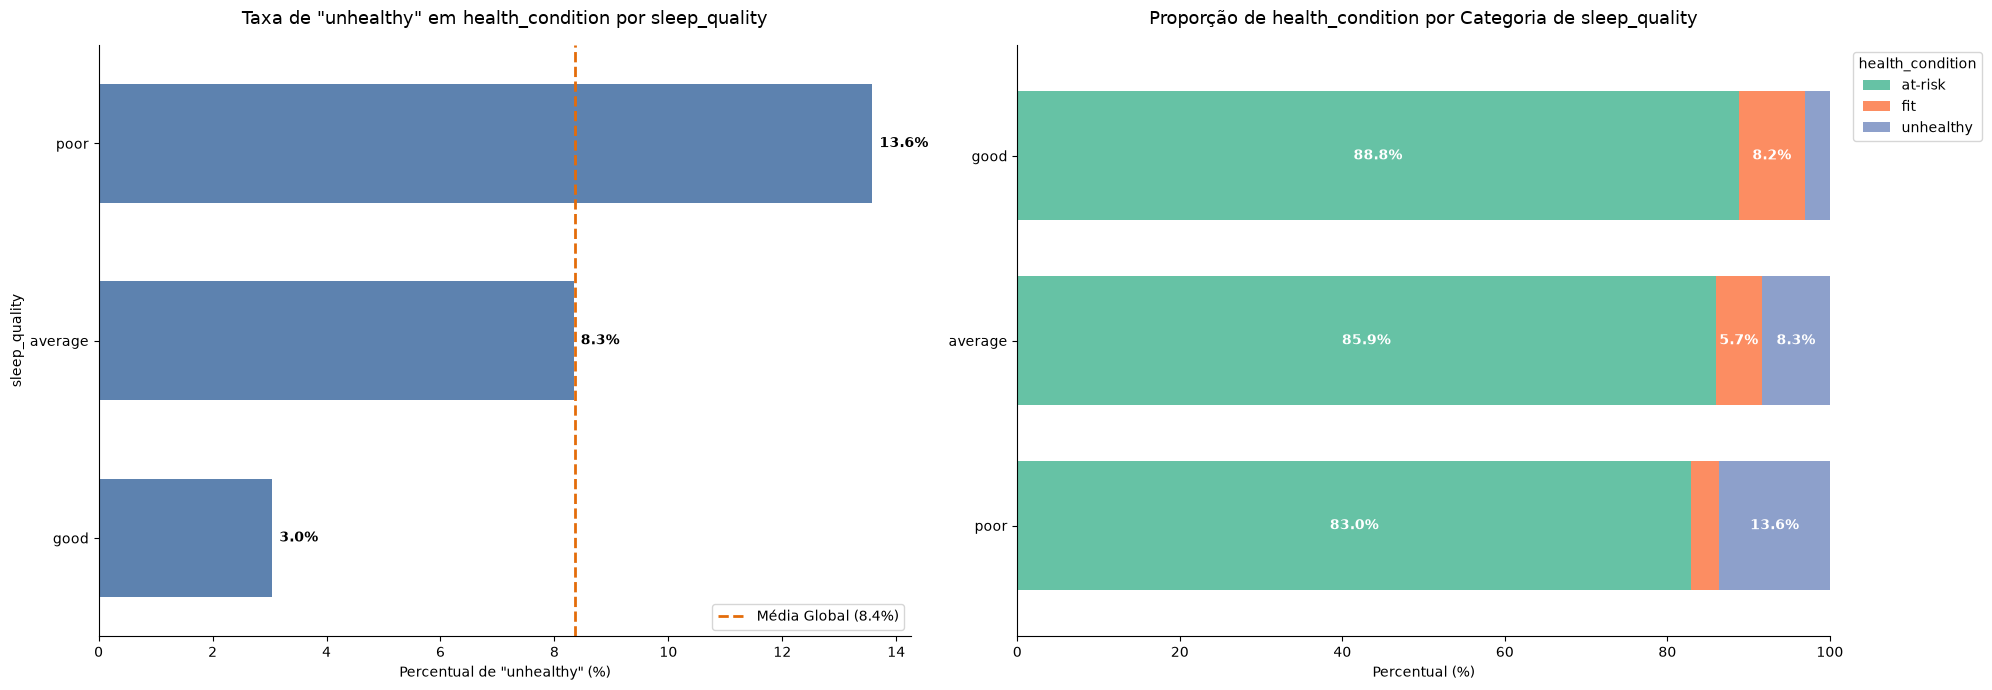

In [60]:
plot_cat_vs_target(df, col_categorica='sleep_quality', col_target='health_condition', target_sucesso='unhealthy')

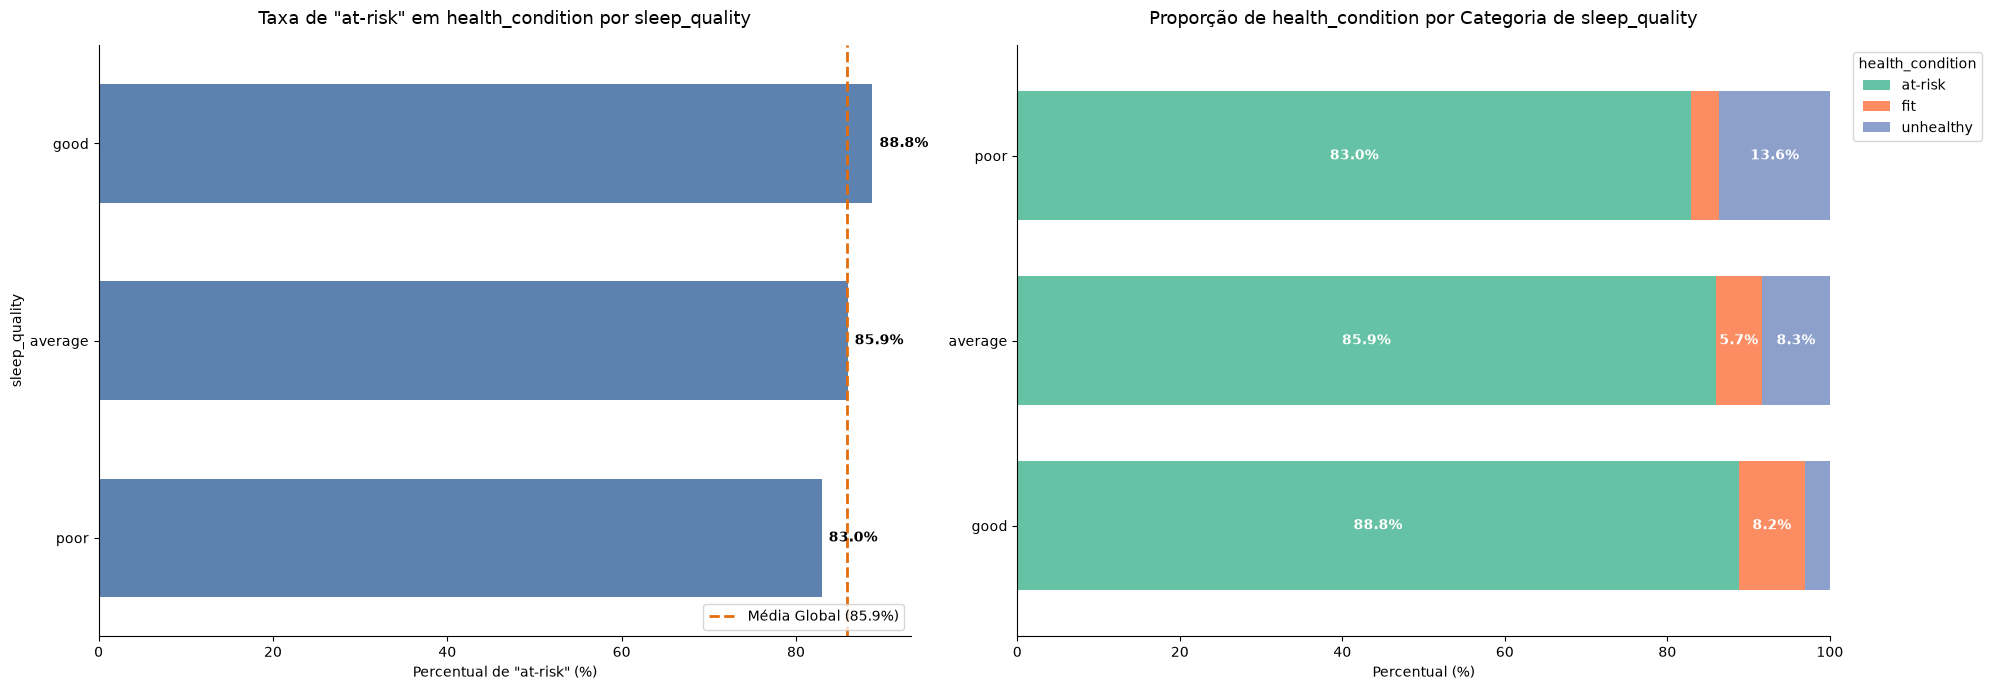

In [61]:
plot_cat_vs_target(df, col_categorica='sleep_quality', col_target='health_condition', target_sucesso='at-risk')

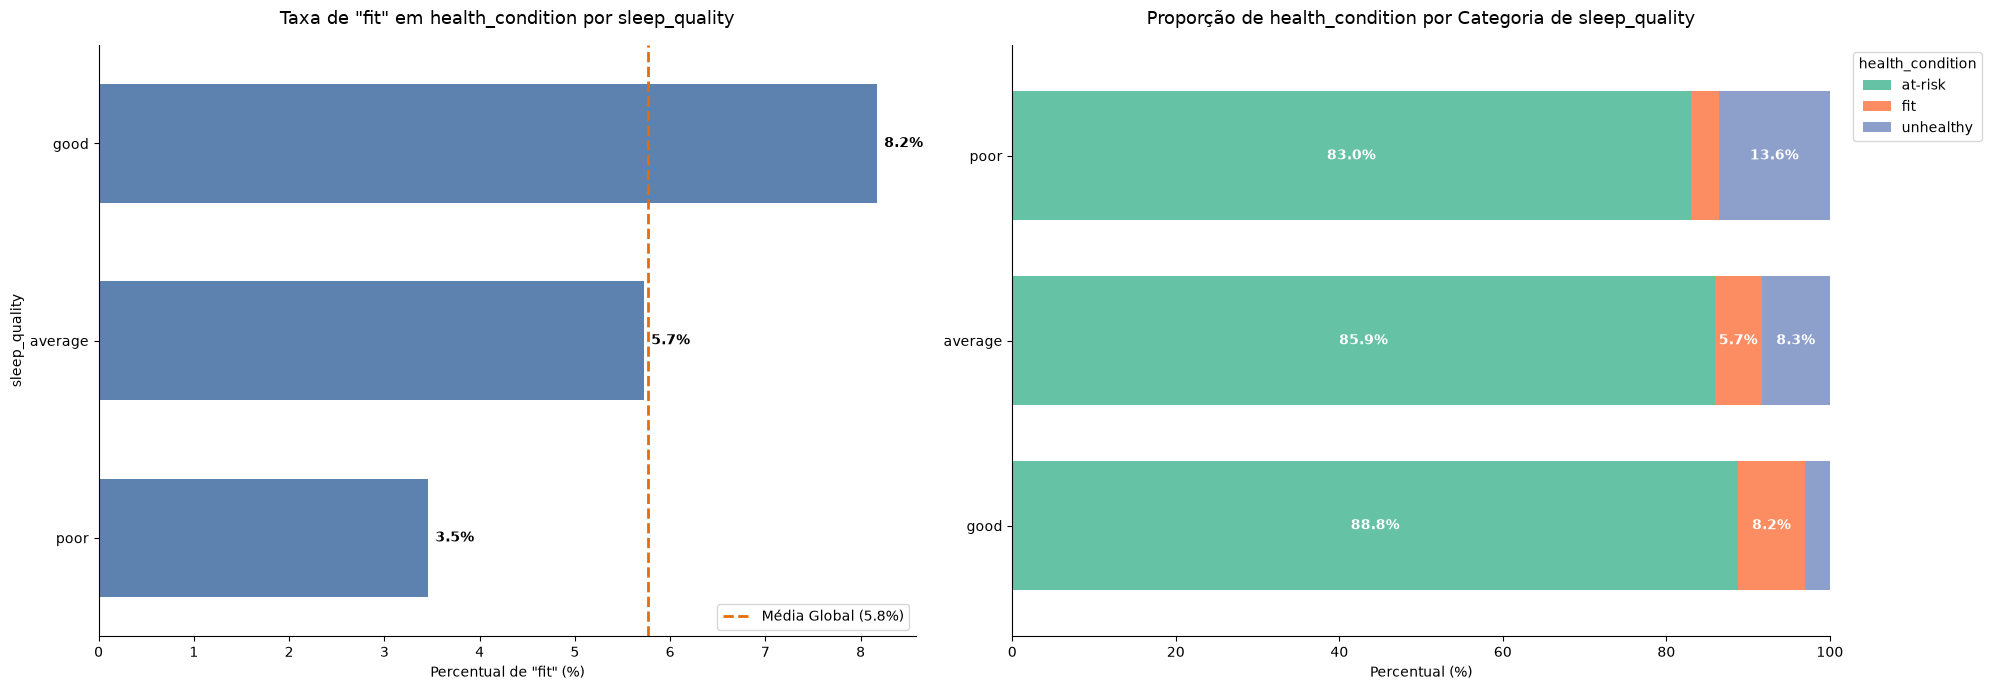

In [62]:
plot_cat_vs_target(df, col_categorica='sleep_quality', col_target='health_condition', target_sucesso='fit')

### Physical Activity Level vs Health Condition

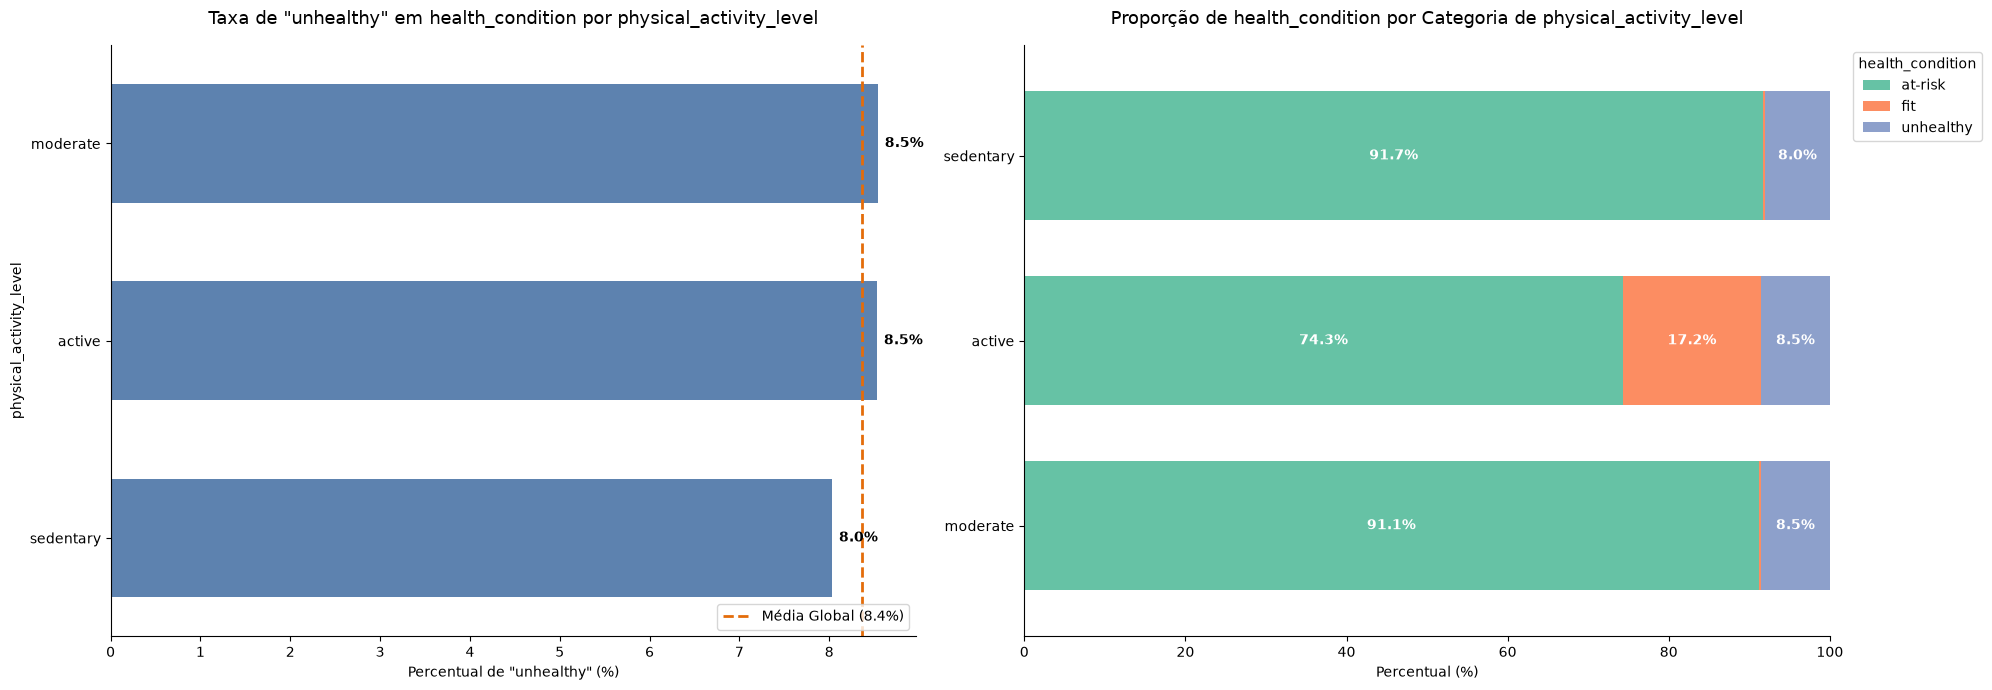

In [63]:
plot_cat_vs_target(df, col_categorica='physical_activity_level', col_target='health_condition', target_sucesso='unhealthy')

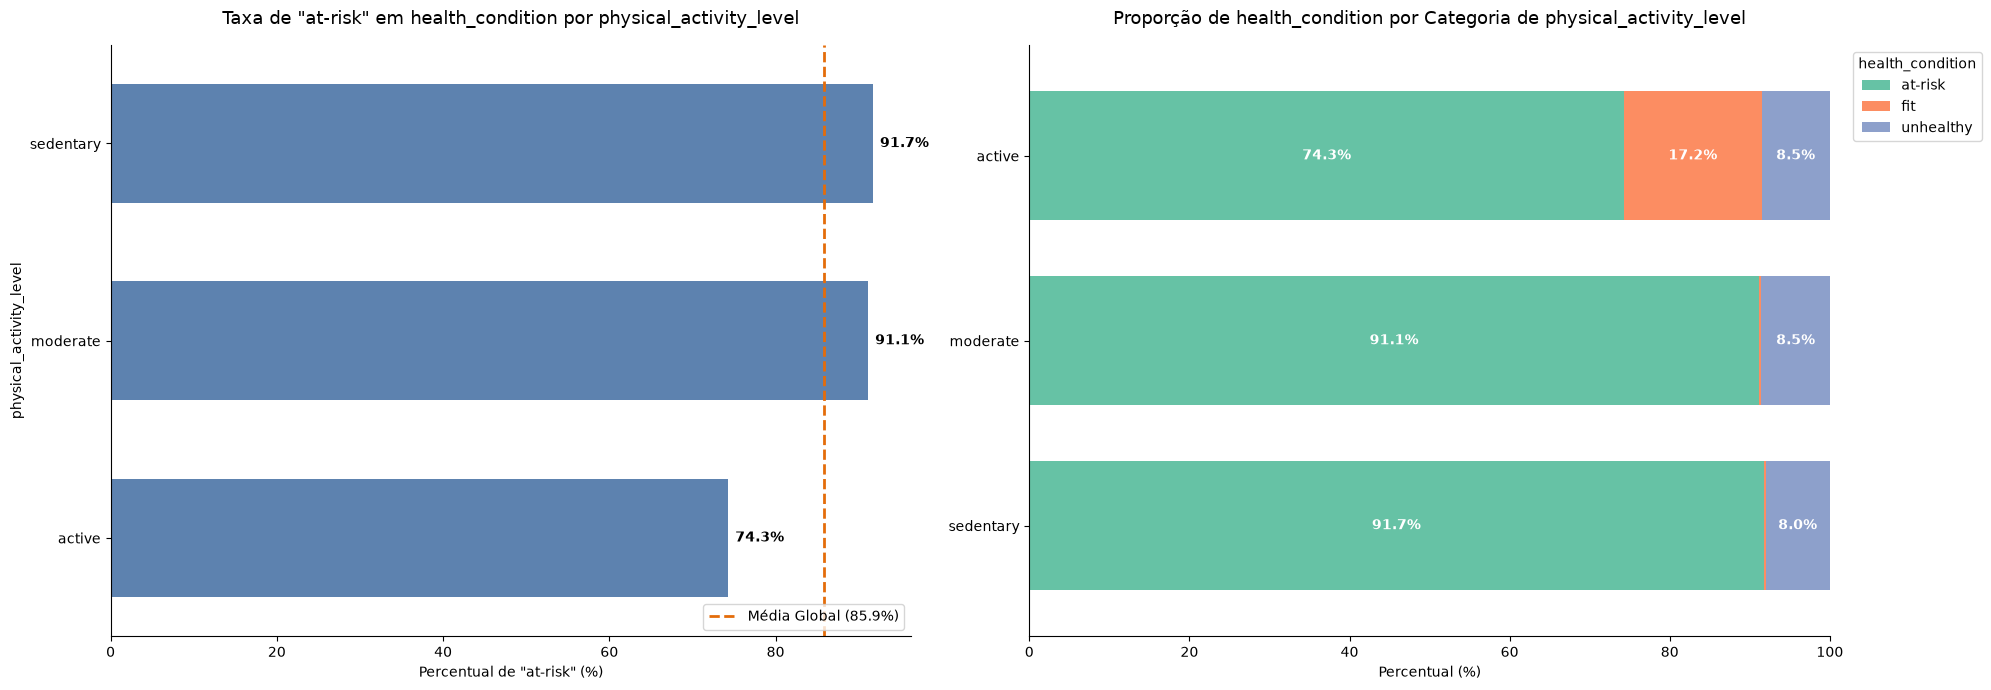

In [64]:
plot_cat_vs_target(df, col_categorica='physical_activity_level', col_target='health_condition', target_sucesso='at-risk')

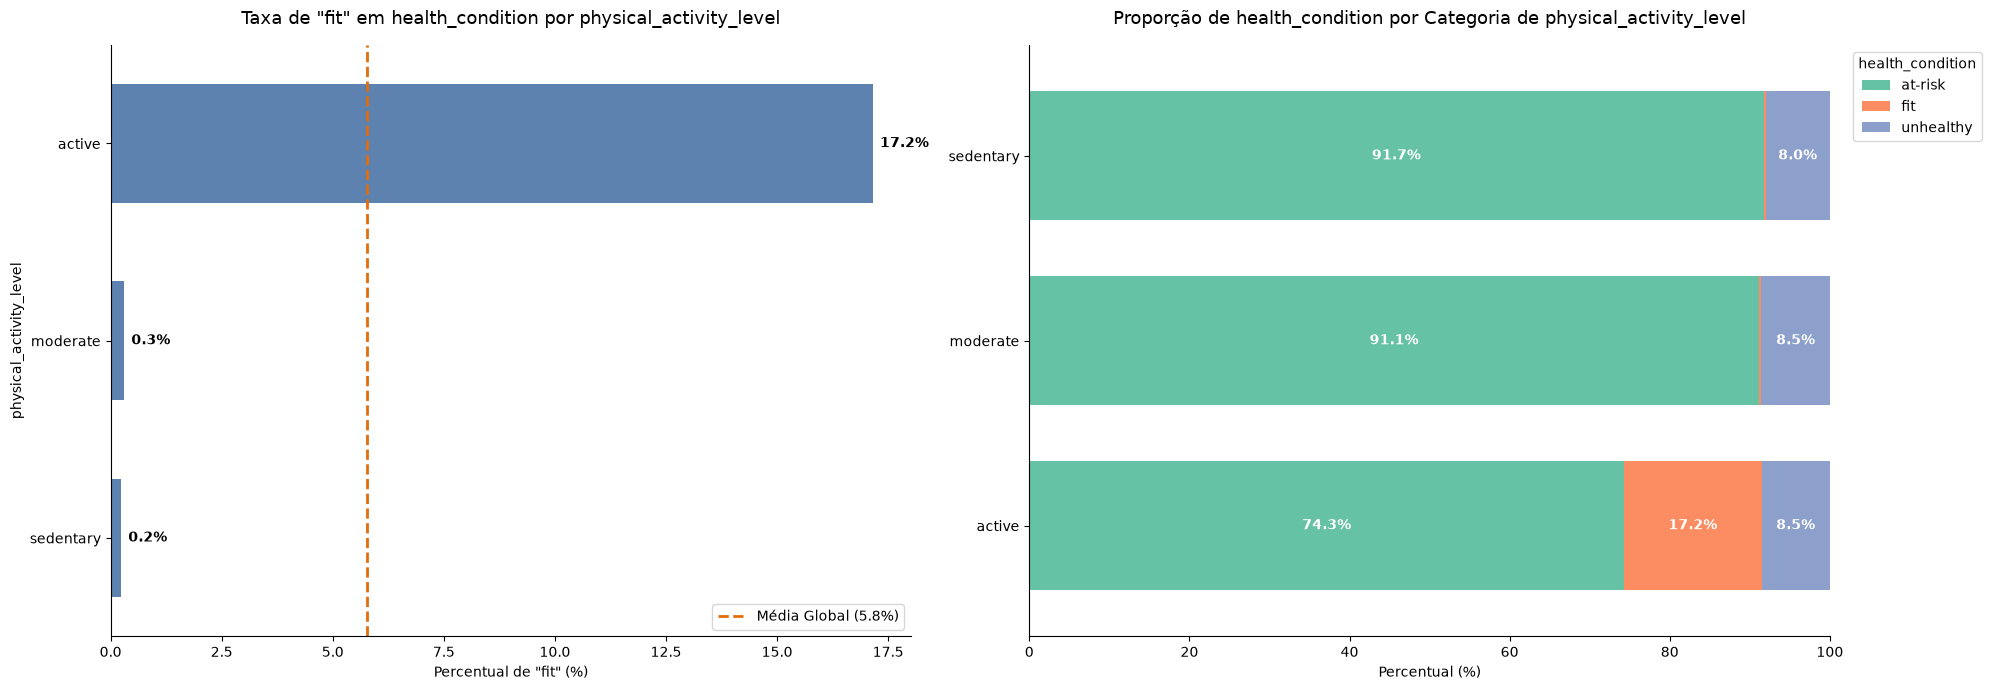

In [65]:
plot_cat_vs_target(df, col_categorica='physical_activity_level', col_target='health_condition', target_sucesso='fit')

### Smoking Alcohol vs Health Condition

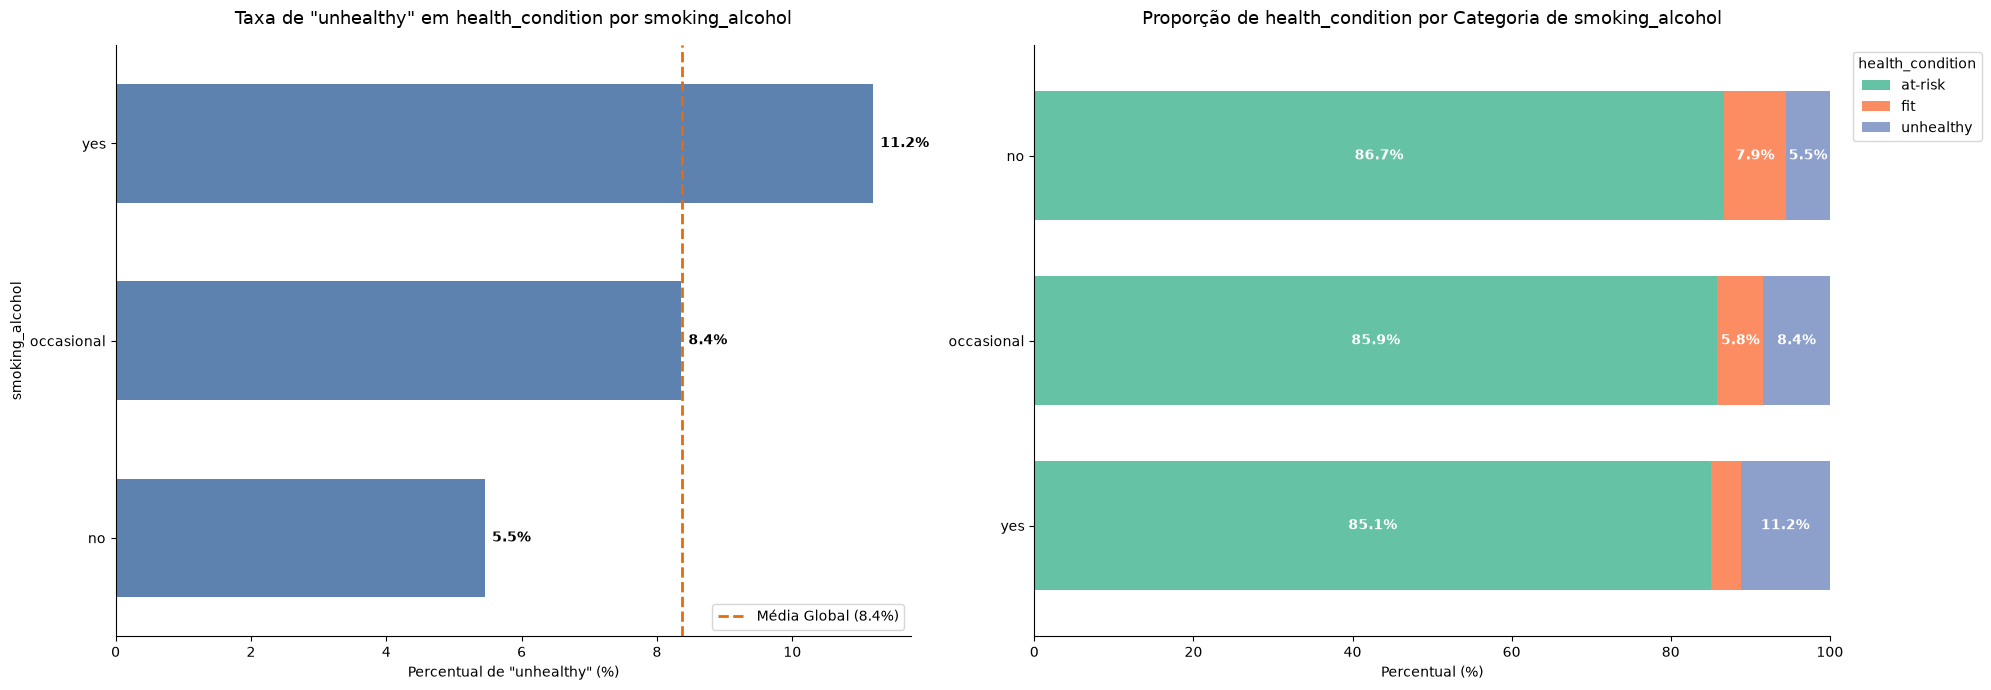

In [66]:
plot_cat_vs_target(df, col_categorica='smoking_alcohol', col_target='health_condition', target_sucesso='unhealthy')

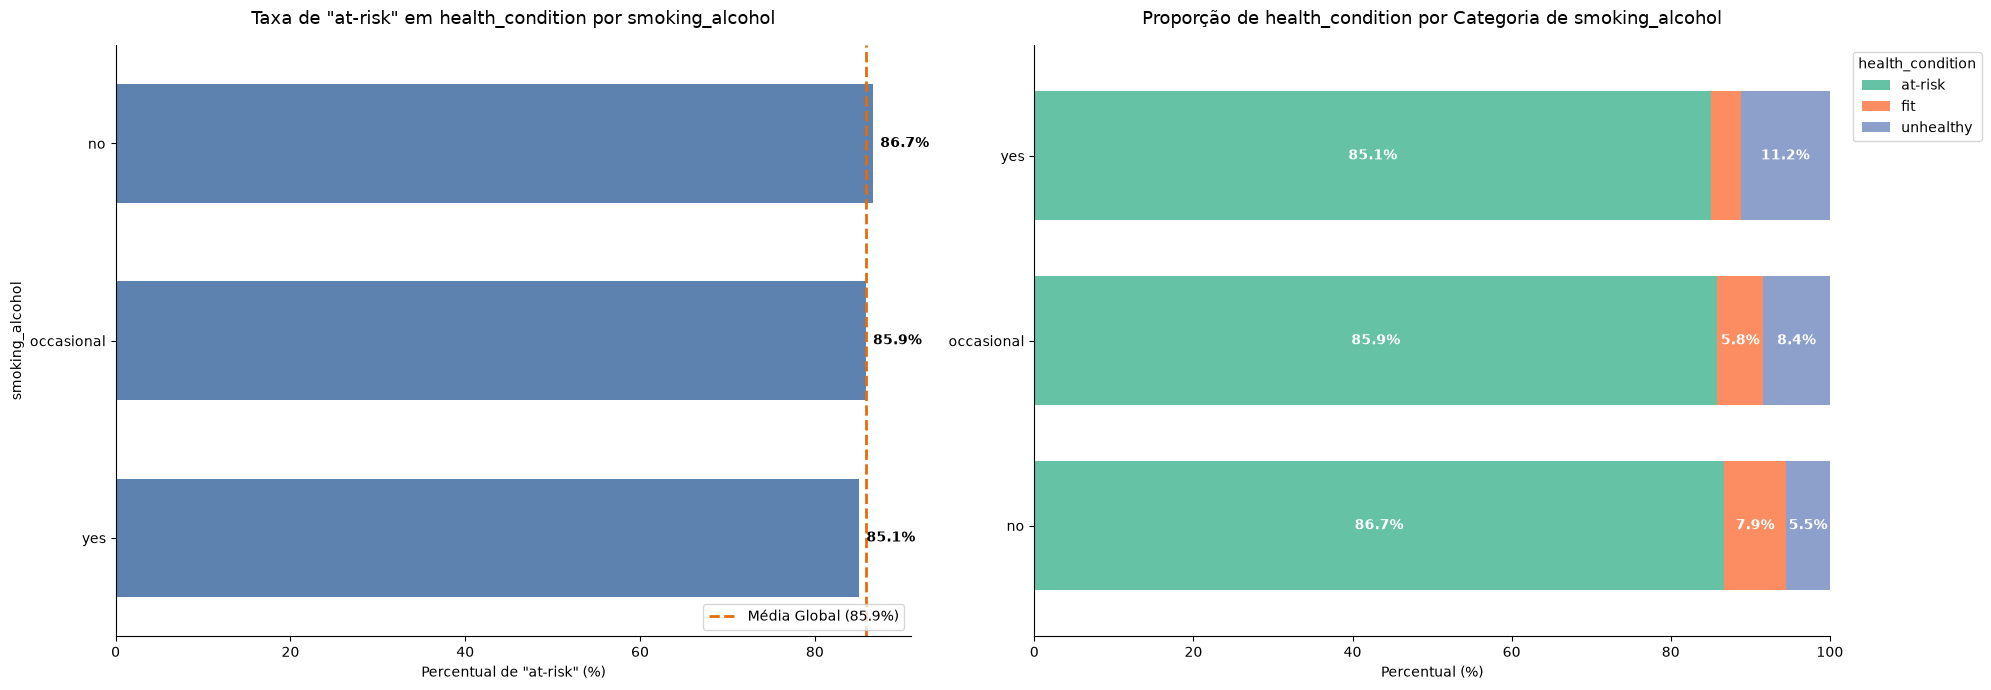

In [67]:
plot_cat_vs_target(df, col_categorica='smoking_alcohol', col_target='health_condition', target_sucesso='at-risk')

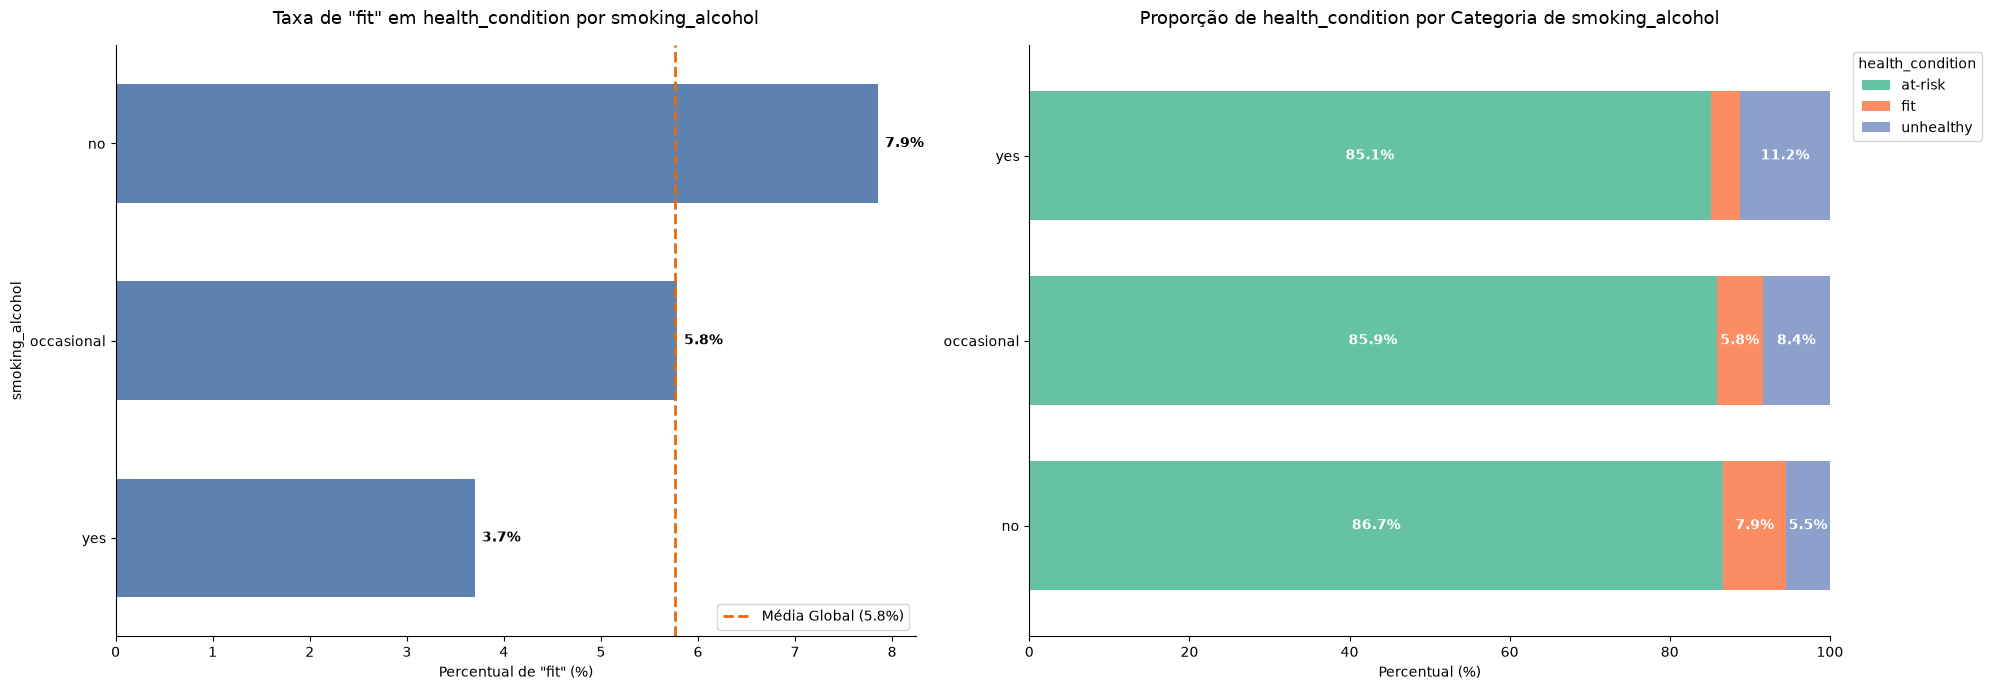

In [68]:
plot_cat_vs_target(df, col_categorica='smoking_alcohol', col_target='health_condition', target_sucesso='fit')

### Gender vs Health Condition

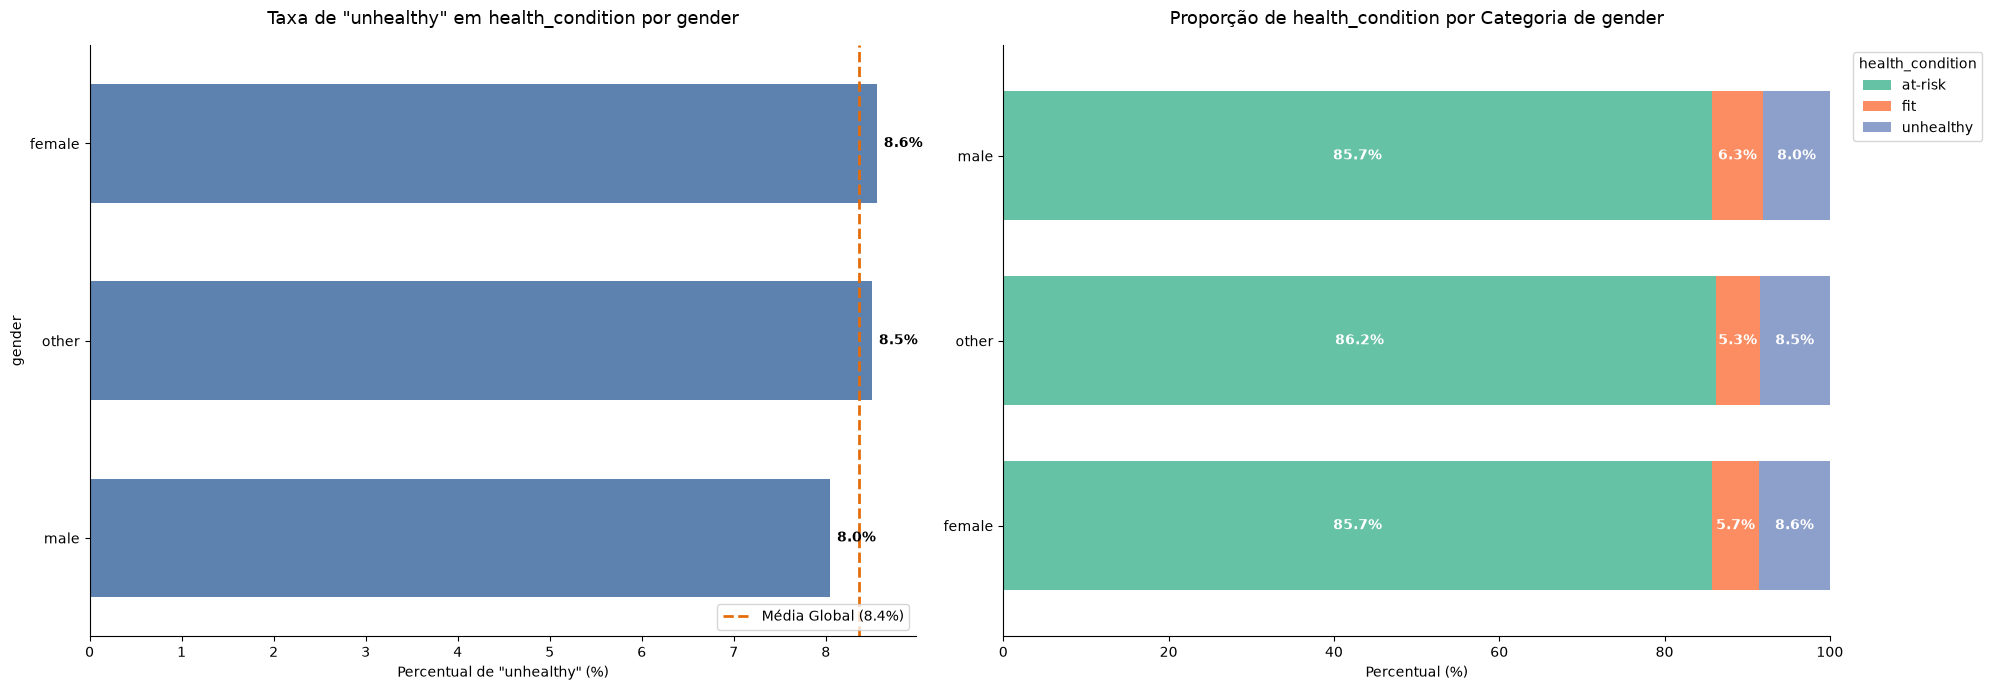

In [69]:
plot_cat_vs_target(df, col_categorica='gender', col_target='health_condition', target_sucesso='unhealthy')

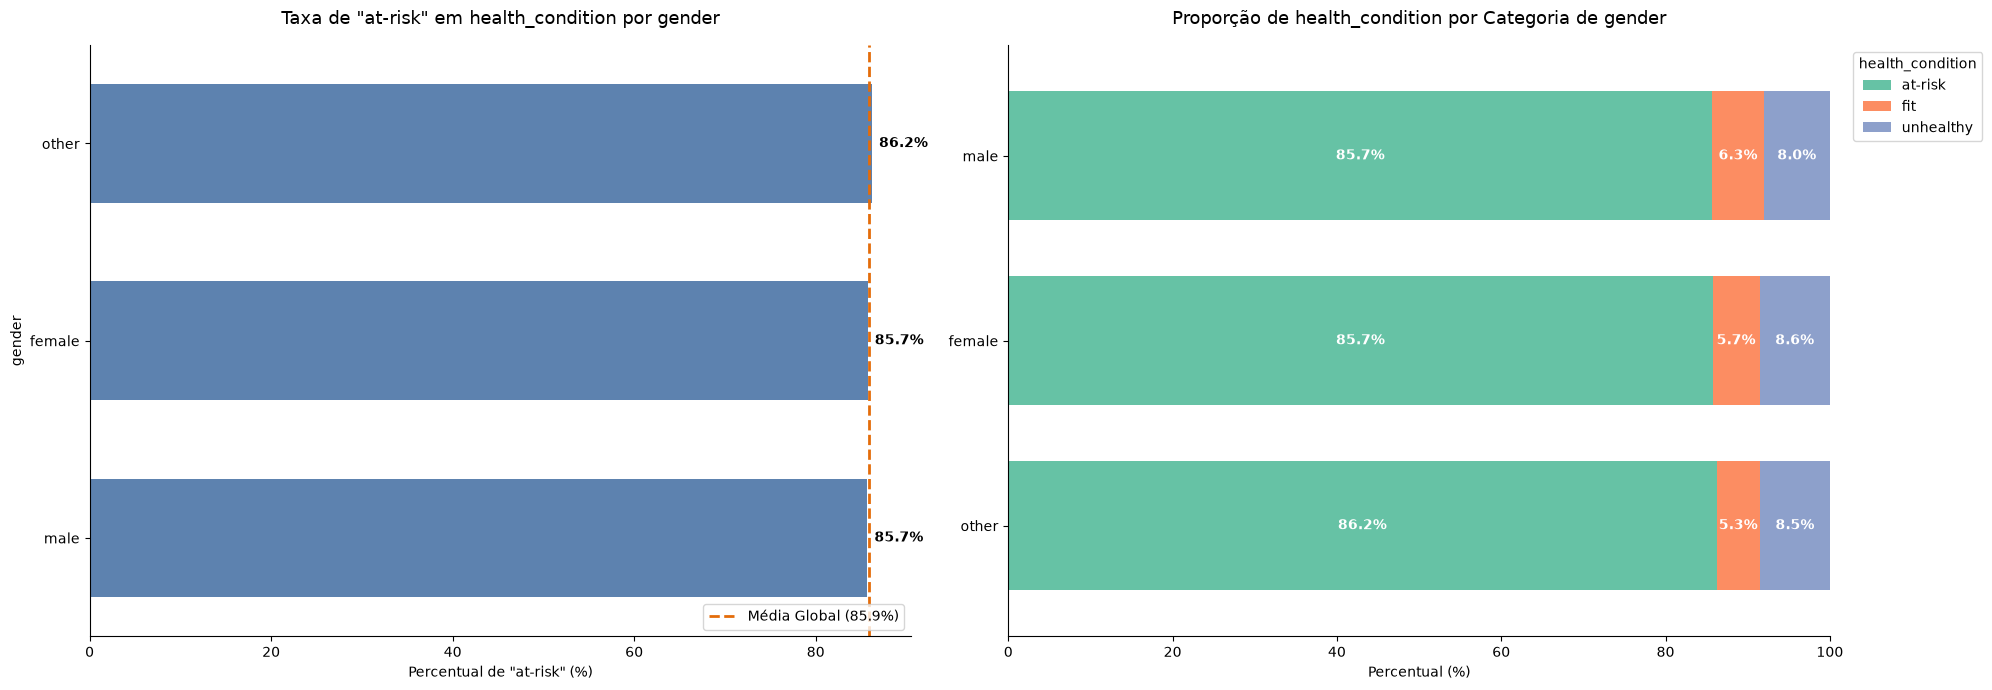

In [70]:
plot_cat_vs_target(df, col_categorica='gender', col_target='health_condition', target_sucesso='at-risk')

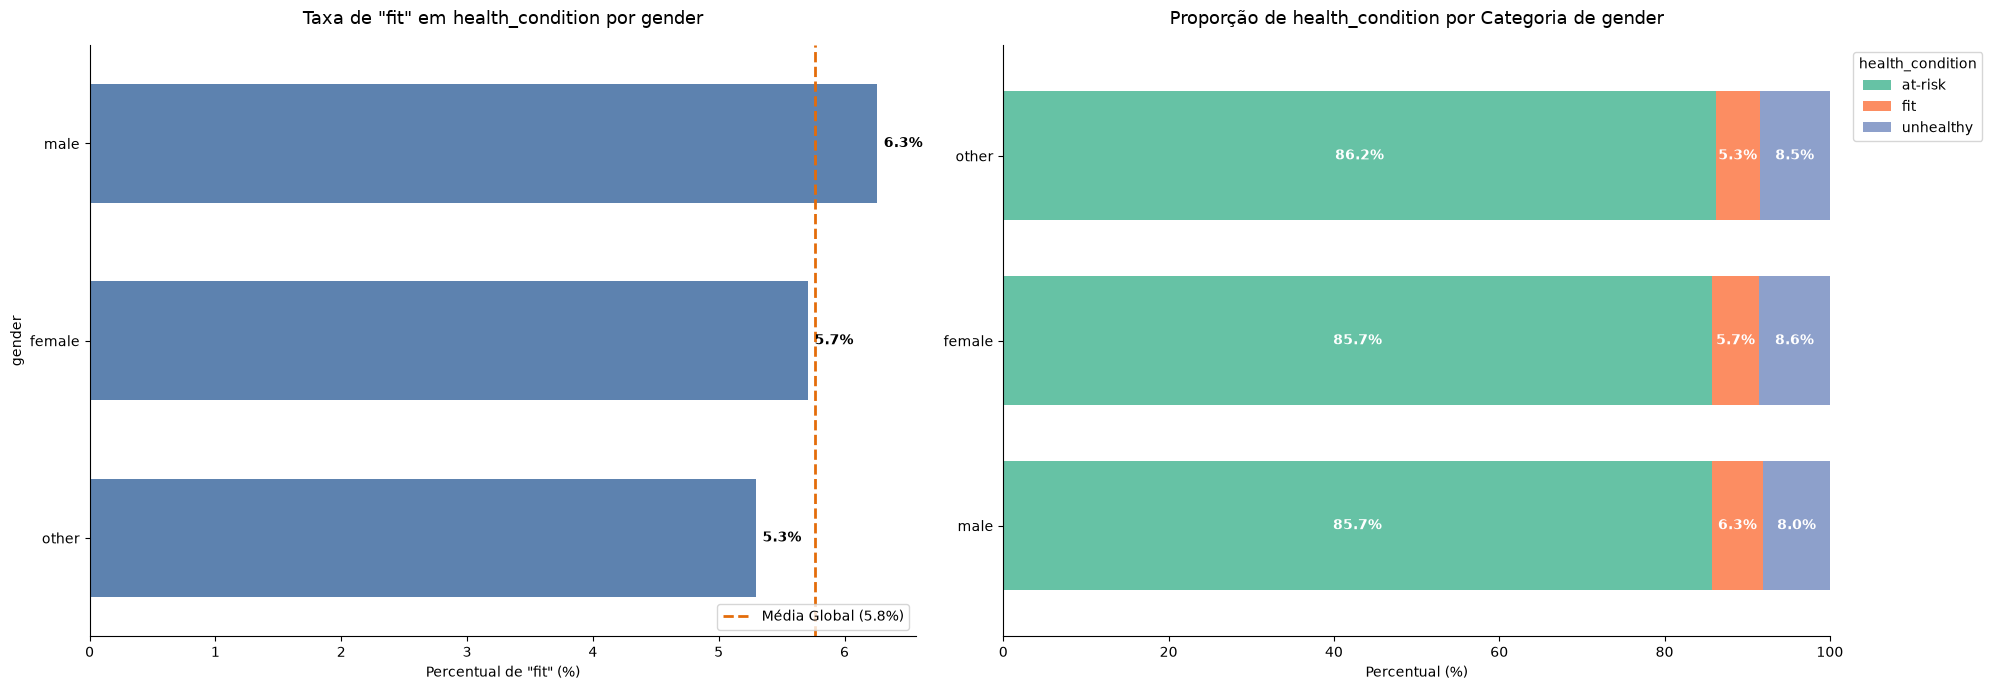

In [71]:
plot_cat_vs_target(df, col_categorica='gender', col_target='health_condition', target_sucesso='fit')

# Split X and y

In [72]:
X_train = df.drop(columns='health_condition')
y_train = df.loc[:, ['health_condition']]

X_test = df_test.copy()

In [73]:
le = LabelEncoder()
y_train['health_condition'] = le.fit_transform(y_train['health_condition'])

In [74]:
dump_pickle(le, '../artifacts/label_encoder.pkl')

In [76]:
X_train.to_parquet('../data/interim/X_train_raw.parquet', engine='fastparquet')
y_train.to_parquet('../data/interim/y_train.parquet', engine='fastparquet')

X_test.to_parquet('../data/interim/X_test_raw.parquet', engine='fastparquet')